In [1]:
from google.colab import files
uploaded = files.upload()



Saving archive (4).zip to archive (4).zip


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Bank Marketing Campaign & Customer Conversion Analytics

## Business Objective

This project analyzes bank marketing campaign data to understand
which customer and campaign characteristics are associated with
term-deposit subscription.

The analysis uses Python, Pandas, NumPy, Matplotlib, Seaborn and
SQLite to move from raw customer-level data to actionable business
insights.

## Key Business Questions

1. What is the overall campaign conversion rate?
2. Which customer segments show stronger conversion?
3. Does previous campaign history affect current conversion?
4. Does repeated contact show signs of diminishing returns?
5. Which contact methods perform better?
6. Which customer segments combine high conversion with meaningful volume?
7. Which findings remain meaningful after statistical validation?
8. How can the bank improve customer targeting?

## Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQLite3
- SQL

**Import Libraries**

---








In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import zipfile
import os
import pandas as pd # Ensure pandas is imported if not already in this cell's context

# Get the uploaded file content from the 'uploaded' dictionary in the kernel state
zip_filename = 'archive (4).zip'
zip_file_path = os.path.join('/content/', zip_filename)
extraction_path = '/content/'

df = None # Initialize df to None

# Check if the file content is available in the 'uploaded' dictionary
if zip_filename in uploaded:
    file_bytes = uploaded[zip_filename]
    try:
        # Write the bytes content to a file on disk
        with open(zip_file_path, 'wb') as f:
            f.write(file_bytes)
        print(f"'{zip_filename}' successfully written to '{zip_file_path}'.")

        # Now proceed with extraction
        try:
            with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
                zip_ref.extractall(extraction_path)
            print(f"'{zip_filename}' extracted successfully to '{extraction_path}'.")

            print("Files in extraction directory:")
            for item in os.listdir(extraction_path):
                print(f"- {item}")

            csv_file_name = "churn_analysis.csv" # Original intended file
            alternative_csv_file_name = "bank-additional-full.csv" # Alternative file

            # Try to load the original intended CSV file
            if os.path.exists(os.path.join(extraction_path, csv_file_name)):
                try:
                    df = pd.read_csv(os.path.join(extraction_path, csv_file_name), encoding='latin-1', sep=';')
                    print(f"DataFrame loaded from '{csv_file_name}' successfully.")
                except (pd.errors.ParserError, Exception) as e:
                    print(f"Warning: Could not load '{csv_file_name}' due to error: {e}")
                    print(f"Attempting to load '{alternative_csv_file_name}' instead.")
            else:
                print(f"'{csv_file_name}' not found after extraction. Attempting to load '{alternative_csv_file_name}' instead.")

            # If df is still None (either original file not found or failed to load), try the alternative
            if df is None and os.path.exists(os.path.join(extraction_path, alternative_csv_file_name)):
                try:
                    df = pd.read_csv(os.path.join(extraction_path, alternative_csv_file_name), encoding='latin-1', sep=';')
                    print(f"DataFrame loaded from '{alternative_csv_file_name}' successfully.")
                except (pd.errors.ParserError, Exception) as e:
                    print(f"Error: Could not load '{alternative_csv_file_name}' either: {e}")
            elif df is None: # Both files not found or failed
                 print(f"Error: Neither '{csv_file_name}' nor '{alternative_csv_file_name}' could be loaded.")

        except zipfile.BadZipFile:
            print(f"Error: '{zip_filename}' is not a valid zip file.")
        except Exception as e:
            print(f"An unexpected error occurred during extraction or reading: {e}")

    except Exception as e:
        print(f"Error writing '{zip_filename}' to disk: {e}")
else:
    print(f"Error: Zip file '{zip_filename}' not found in the 'uploaded' dictionary. Please ensure it was uploaded correctly.")

'archive (4).zip' successfully written to '/content/archive (4).zip'.
'archive (4).zip' extracted successfully to '/content/'.
Files in extraction directory:
- .config
- drive
- bank-additional-full.csv
- archive (4).zip
- sample_data
'churn_analysis.csv' not found after extraction. Attempting to load 'bank-additional-full.csv' instead.
DataFrame loaded from 'bank-additional-full.csv' successfully.


 **CREATE SQLITE CONNECTION**


---




In [5]:
import sqlite3

conn = sqlite3.connect(
    "/content/bank_marketing.db"
)

print("SQLite database connected.")

SQLite database connected.


In [6]:
import pandas as pd
import zipfile
import os

# Ensure the required file exists before attempting to read it.
csv_file_path = '/content/bank-additional-full.csv'
zip_file_name_in_uploaded = 'archive (4) (5).zip' # Correct name from `uploaded` dictionary

# Check if the CSV file already exists
if not os.path.exists(csv_file_path):
    print(f"'{csv_file_path}' not found. Attempting to extract from zip.")
    if zip_file_name_in_uploaded in uploaded:
        zip_path_on_disk = os.path.join('/content/', zip_file_name_in_uploaded)

        # Write the zip file to disk if it's only in memory (from 'uploaded')
        if not os.path.exists(zip_path_on_disk):
            with open(zip_path_on_disk, 'wb') as f:
                f.write(uploaded[zip_file_name_in_uploaded])
            print(f"Zip file '{zip_file_name_in_uploaded}' written to disk.")

        try:
            with zipfile.ZipFile(zip_path_on_disk, 'r') as zip_ref:
                zip_ref.extractall('/content/')
            print(f"'{zip_file_name_in_uploaded}' extracted successfully.")
        except zipfile.BadZipFile:
            print(f"Error: '{zip_file_name_in_uploaded}' is not a valid zip file.")
        except Exception as e:
            print(f"An unexpected error occurred during zip extraction: {e}")
    else:
        print(f"Error: Zip file '{zip_file_name_in_uploaded}' not found in the 'uploaded' dictionary.")

# Proceed if the CSV file now exists
if os.path.exists(csv_file_path):
    df = pd.read_csv(csv_file_path, encoding='latin-1', sep=';')

    df.to_sql(
        "customers_raw",
        conn,
        if_exists="replace",
        index=False
    )

    print("customers_raw table created.")
else:
    print(f"Failed to create 'customers_raw' table: '{csv_file_path}' could not be found or extracted.")

customers_raw table created.


In [7]:
sql_check = pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_rows
    FROM customers_raw;
    """,
    conn
)

print("Pandas rows :", len(df))
print("SQLite rows :", sql_check.loc[0, "total_rows"])

Pandas rows : 41188
SQLite rows : 41188


In [8]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 41,188
Columns : 21


In [9]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [10]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [12]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 12


In [13]:
duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 0.03%


In [14]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_values")
)

missing["missing_percentage"] = (
    missing["missing_values"]
    / len(df)
    * 100
).round(2)

missing = (
    missing
    .sort_values("missing_percentage", ascending=False)
)

missing

,missing_values,missing_percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
month,0,0.0
day_of_week,0,0.0


In [15]:
df["y"].value_counts(normalize=True).mul(100).round(2)

,proportion
y,
no,88.73
yes,11.27


In [16]:
# Count "unknown" values in every column

unknown_summary = (
    df.astype(str)
      .apply(lambda col: col.str.strip().str.lower().eq("unknown").sum())
      .to_frame("unknown_count")
)

unknown_summary["unknown_percentage"] = (
    unknown_summary["unknown_count"]
    / len(df)
    * 100
).round(2)

unknown_summary = (
    unknown_summary[
        unknown_summary["unknown_count"] > 0
    ]
    .sort_values(
        "unknown_percentage",
        ascending=False
    )
)

unknown_summary

,unknown_count,unknown_percentage
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


In [17]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(df[col].value_counts(dropna=False))


job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

In [18]:
df_clean = df.copy()

In [19]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

after = len(df_clean)

print(f"Rows before removing duplicates : {before:,}")
print(f"Rows after removing duplicates  : {after:,}")
print(f"Duplicates removed              : {before - after:,}")

Rows before removing duplicates : 41,188
Rows after removing duplicates  : 41,176
Duplicates removed              : 12


In [20]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

df_clean.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed',
 'y']

In [120]:
categorical_columns = df_clean.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    df_clean[col] = (
        df_clean[col]
        .str.strip()
        .str.lower()
    )

In [22]:
df_clean.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [23]:
df_clean["subscribed_flag"] = (
    df_clean["y"]
    .eq("yes")
    .astype(int)
)

In [24]:
target_check = (
    df_clean
    .groupby("y")["subscribed_flag"]
    .agg(["count", "sum"])
)

target_check

,count,sum
y,,
no,36537,0
yes,4639,4639


In [25]:
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

df_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp_var_rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons_price_idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons_conf_idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr_employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


In [26]:
cleaning_summary = pd.DataFrame({
    "metric": [
        "Original rows",
        "Final rows",
        "Duplicates removed",
        "Columns"
    ],
    "value": [
        len(df),
        len(df_clean),
        len(df) - len(df_clean),
        df_clean.shape[1]
    ]
})

cleaning_summary

,metric,value
0,Original rows,41188
1,Final rows,41176
2,Duplicates removed,12
3,Columns,22


In [27]:
df_clean.to_sql(
    "customers_clean",
    conn,
    if_exists="replace",
    index=False
)

print("customers_clean table created successfully.")

customers_clean table created successfully.


In [28]:
pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_customers
    FROM customers_clean;
    """,
    conn
)

,total_customers
0,41176


In [29]:
# Create age segments for customer analysis

age_bins = [0, 25, 35, 45, 55, 65, np.inf]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [30]:
df_clean[["age", "age_group"]].head(10)

,age,age_group
0,56,56-65
1,57,56-65
2,37,36-45
3,40,36-45
4,56,56-65
5,45,36-45
6,59,56-65
7,41,36-45
8,24,18-25
9,25,18-25


In [31]:
df_clean["age_group"].value_counts().sort_index()

,count
age_group,
18-25,1665
26-35,14844
36-45,12839
46-55,8247
56-65,2963
66+,618


In [32]:
df_clean["previously_contacted"] = np.where(
    df_clean["pdays"] == 999,
    "No",
    "Yes"
)

In [33]:
df_clean["previously_contacted"].value_counts()

,count
previously_contacted,
No,39661
Yes,1515


In [34]:
duration_bins = [0, 120, 300, 600, np.inf]

duration_labels = [
    "0-2 min",
    "2-5 min",
    "5-10 min",
    "10+ min"
]

df_clean["duration_group"] = pd.cut(
    df_clean["duration"],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

In [35]:
df_clean["duration_group"].value_counts().sort_index()

,count
duration_group,
0-2 min,12912
2-5 min,17062
5-10 min,7738
10+ min,3464


In [36]:
df_clean.to_sql(
    "customers_clean",
    conn,
    if_exists="replace",
    index=False
)

print("customers_clean updated successfully.")

customers_clean updated successfully.


In [37]:
# Overall campaign KPIs

total_customers = len(df_clean)

total_subscriptions = df_clean["subscribed_flag"].sum()

overall_conversion_rate = (
    total_subscriptions / total_customers * 100
)

non_conversion_rate = 100 - overall_conversion_rate

print(f"Total customers contacted : {total_customers:,}")
print(f"Total subscriptions       : {total_subscriptions:,}")
print(f"Conversion rate           : {overall_conversion_rate:.2f}%")
print(f"Non-conversion rate       : {non_conversion_rate:.2f}%")

Total customers contacted : 41,176
Total subscriptions       : 4,639
Conversion rate           : 11.27%
Non-conversion rate       : 88.73%


In [38]:
campaign_kpis = pd.DataFrame({
    "KPI": [
        "Customers Contacted",
        "Subscriptions",
        "Conversion Rate",
        "Non-Conversion Rate"
    ],
    "Value": [
        total_customers,
        total_subscriptions,
        f"{overall_conversion_rate:.2f}%",
        f"{non_conversion_rate:.2f}%"
    ]
})

campaign_kpis

,KPI,Value
0,Customers Contacted,41176
1,Subscriptions,4639
2,Conversion Rate,11.27%
3,Non-Conversion Rate,88.73%


In [39]:
target_validation = (
    df_clean
    .groupby("y")
    .agg(
        customers=("y", "size"),
        subscriptions=("subscribed_flag", "sum")
    )
    .reset_index()
)

target_validation

,y,customers,subscriptions
0,no,36537,0
1,yes,4639,4639


In [40]:
baseline_sql = """
SELECT
    COUNT(*) AS total_customers,

    SUM(
        CASE
            WHEN y = 'yes' THEN 1
            ELSE 0
        END
    ) AS subscriptions,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN y = 'yes' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS conversion_rate

FROM customers_clean;
"""

baseline_sql_result = pd.read_sql_query(
    baseline_sql,
    conn
)

baseline_sql_result

,total_customers,subscriptions,conversion_rate
0,41176,4639,11.27


### Baseline Interpretation

The campaign contacted **X customers** and generated **Y term-deposit
subscriptions**, resulting in an overall conversion rate of **Z%**.

This conversion rate will be used as the baseline for subsequent
segment-level lift and opportunity analysis.

In [41]:
def conversion_analysis(df, column, target="subscribed_flag"):
    """
    Calculate conversion metrics for each category
    of a given variable.
    """

    result = (
        df.groupby(column, dropna=False)
          .agg(
              customers=(target, "size"),
              subscriptions=(target, "sum"),
              conversion_rate=(target, "mean")
          )
          .reset_index()
    )

    # Convert rate to percentage
    result["conversion_rate"] = (
        result["conversion_rate"] * 100
    ).round(2)

    # Percentage of total customers
    result["customer_share"] = (
        result["customers"] / len(df) * 100
    ).round(2)

    # Difference from overall campaign rate
    result["lift_vs_baseline"] = (
        result["conversion_rate"] - overall_conversion_rate
    ).round(2)

    # Sort by conversion rate
    result = result.sort_values(
        "conversion_rate",
        ascending=False
    ).reset_index(drop=True)

    return result

In [42]:
age_analysis = conversion_analysis(
    df_clean,
    "age_group"
)

age_analysis

/tmp/ipykernel_1860/3311601019.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(column, dropna=False)


,age_group,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline
0,66+,618,290,46.93,1.50,35.66
1,18-25,1665,349,20.96,4.04,9.69
2,56-65,2963,451,15.22,7.20,3.95
3,26-35,14844,1740,11.72,36.05,0.45
4,46-55,8247,717,8.69,20.03,-2.58
5,36-45,12839,1092,8.51,31.18,-2.76


In [43]:
job_analysis = conversion_analysis(
    df_clean,
    "job"
)

job_analysis

,job,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline
0,student,875,275,31.43,2.13,20.16
1,retired,1718,434,25.26,4.17,13.99
2,unemployed,1014,144,14.20,2.46,2.93
3,admin.,10419,1351,12.97,25.30,1.70
4,management,2924,328,11.22,7.10,-0.05
5,unknown,330,37,11.21,0.80,-0.06
6,technician,6739,730,10.83,16.37,-0.44
7,self-employed,1421,149,10.49,3.45,-0.78
8,housemaid,1060,106,10.00,2.57,-1.27
9,entrepreneur,1456,124,8.52,3.54,-2.75


In [44]:
education_analysis = conversion_analysis(
    df_clean,
    "education"
)

education_analysis

,education,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline
0,illiterate,18,4,22.22,0.04,10.95
1,unknown,1730,251,14.51,4.20,3.24
2,university.degree,12164,1669,13.72,29.54,2.45
3,professional.course,5240,595,11.35,12.73,0.08
4,high.school,9512,1031,10.84,23.10,-0.43
5,basic.4y,4176,428,10.25,10.14,-1.02
6,basic.6y,2291,188,8.21,5.56,-3.06
7,basic.9y,6045,473,7.82,14.68,-3.45


In [45]:
housing_analysis = conversion_analysis(
    df_clean,
    "housing"
)

housing_analysis

,housing,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline
0,yes,21571,2507,11.62,52.39,0.35
1,no,18615,2025,10.88,45.21,-0.39
2,unknown,990,107,10.81,2.40,-0.46


In [46]:
MIN_CUSTOMERS = 300

job_opportunities = (
    job_analysis[
        job_analysis["customers"] >= MIN_CUSTOMERS
    ]
    .copy()
)

job_opportunities

,job,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline
0,student,875,275,31.43,2.13,20.16
1,retired,1718,434,25.26,4.17,13.99
2,unemployed,1014,144,14.20,2.46,2.93
3,admin.,10419,1351,12.97,25.30,1.70
4,management,2924,328,11.22,7.10,-0.05
5,unknown,330,37,11.21,0.80,-0.06
6,technician,6739,730,10.83,16.37,-0.44
7,self-employed,1421,149,10.49,3.45,-0.78
8,housemaid,1060,106,10.00,2.57,-1.27
9,entrepreneur,1456,124,8.52,3.54,-2.75


In [47]:
job_opportunities["opportunity_rank"] = (
    job_opportunities[
        "lift_vs_baseline"
    ]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

job_opportunities

,job,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,opportunity_rank
0,student,875,275,31.43,2.13,20.16,1
1,retired,1718,434,25.26,4.17,13.99,2
2,unemployed,1014,144,14.20,2.46,2.93,3
3,admin.,10419,1351,12.97,25.30,1.70,4
4,management,2924,328,11.22,7.10,-0.05,5
5,unknown,330,37,11.21,0.80,-0.06,6
6,technician,6739,730,10.83,16.37,-0.44,7
7,self-employed,1421,149,10.49,3.45,-0.78,8
8,housemaid,1060,106,10.00,2.57,-1.27,9
9,entrepreneur,1456,124,8.52,3.54,-2.75,10


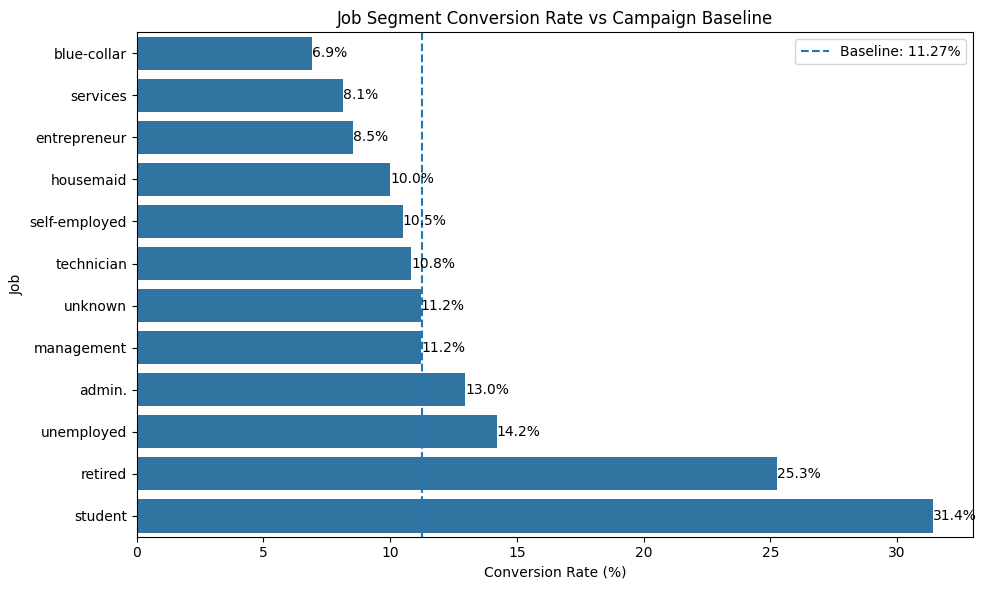

In [48]:
plot_data = job_opportunities.sort_values(
    "conversion_rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_data,
    x="conversion_rate",
    y="job"
)

plt.axvline(
    overall_conversion_rate,
    linestyle="--",
    label=f"Baseline: {overall_conversion_rate:.2f}%"
)

plt.title(
    "Job Segment Conversion Rate vs Campaign Baseline"
)

plt.xlabel("Conversion Rate (%)")
plt.ylabel("Job")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.legend()
plt.tight_layout()
plt.show()

In [49]:
segment_analysis = (
    df_clean
    .groupby(
        ["poutcome", "contact"],
        dropna=False
    )
    .agg(
        customers=("subscribed_flag", "size"),
        subscriptions=("subscribed_flag", "sum")
    )
    .reset_index()
)

segment_analysis["conversion_rate"] = (
    segment_analysis["subscriptions"]
    / segment_analysis["customers"]
    * 100
).round(2)

segment_analysis["customer_share"] = (
    segment_analysis["customers"]
    / len(df_clean)
    * 100
).round(2)

segment_analysis["lift_vs_baseline"] = (
    segment_analysis["conversion_rate"]
    - overall_conversion_rate
).round(2)

segment_analysis

,poutcome,contact,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline
0,failure,cellular,3952,571,14.45,9.60,3.18
1,failure,telephone,300,34,11.33,0.73,0.06
2,nonexistent,cellular,20913,2453,11.73,50.79,0.46
3,nonexistent,telephone,14638,687,4.69,35.55,-6.58
4,success,cellular,1270,828,65.20,3.08,53.93
5,success,telephone,103,66,64.08,0.25,52.81


In [50]:
MIN_SEGMENT_SIZE = 500

segment_opportunities = (
    segment_analysis[
        segment_analysis["customers"] >= MIN_SEGMENT_SIZE
    ]
    .copy()
)

In [51]:
segment_opportunities

,poutcome,contact,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline
0,failure,cellular,3952,571,14.45,9.60,3.18
2,nonexistent,cellular,20913,2453,11.73,50.79,0.46
3,nonexistent,telephone,14638,687,4.69,35.55,-6.58
4,success,cellular,1270,828,65.20,3.08,53.93


In [52]:
segment_opportunities["relative_lift"] = (
    segment_opportunities["conversion_rate"]
    / overall_conversion_rate
).round(2)

In [53]:
segment_opportunities = (
    segment_opportunities
    .sort_values(
        ["relative_lift", "customers"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

segment_opportunities["rank"] = (
    segment_opportunities.index + 1
)

segment_opportunities

,poutcome,contact,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift,rank
0,success,cellular,1270,828,65.20,3.08,53.93,5.79,1
1,failure,cellular,3952,571,14.45,9.60,3.18,1.28,2
2,nonexistent,cellular,20913,2453,11.73,50.79,0.46,1.04,3
3,nonexistent,telephone,14638,687,4.69,35.55,-6.58,0.42,4


In [54]:
segment_opportunities["opportunity"] = np.select(
    [
        (
            (segment_opportunities["relative_lift"] >= 1.5) &
            (segment_opportunities["customers"] >= 500)
        ),

        (
            segment_opportunities["relative_lift"] >= 1.0
        )
    ],
    [
        "High Opportunity",
        "Above Baseline"
    ],
    default="Below Baseline"
)

segment_opportunities


,poutcome,contact,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift,rank,opportunity
0,success,cellular,1270,828,65.20,3.08,53.93,5.79,1,High Opportunity
1,failure,cellular,3952,571,14.45,9.60,3.18,1.28,2,Above Baseline
2,nonexistent,cellular,20913,2453,11.73,50.79,0.46,1.04,3,Above Baseline
3,nonexistent,telephone,14638,687,4.69,35.55,-6.58,0.42,4,Below Baseline


In [55]:
final_segment_table = (
    segment_opportunities[
        [
            "rank",
            "poutcome",
            "contact",
            "customers",
            "subscriptions",
            "conversion_rate",
            "customer_share",
            "relative_lift",
            "opportunity"
        ]
    ]
)

final_segment_table

,rank,poutcome,contact,customers,subscriptions,conversion_rate,customer_share,relative_lift,opportunity
0,1,success,cellular,1270,828,65.20,3.08,5.79,High Opportunity
1,2,failure,cellular,3952,571,14.45,9.60,1.28,Above Baseline
2,3,nonexistent,cellular,20913,2453,11.73,50.79,1.04,Above Baseline
3,4,nonexistent,telephone,14638,687,4.69,35.55,0.42,Below Baseline


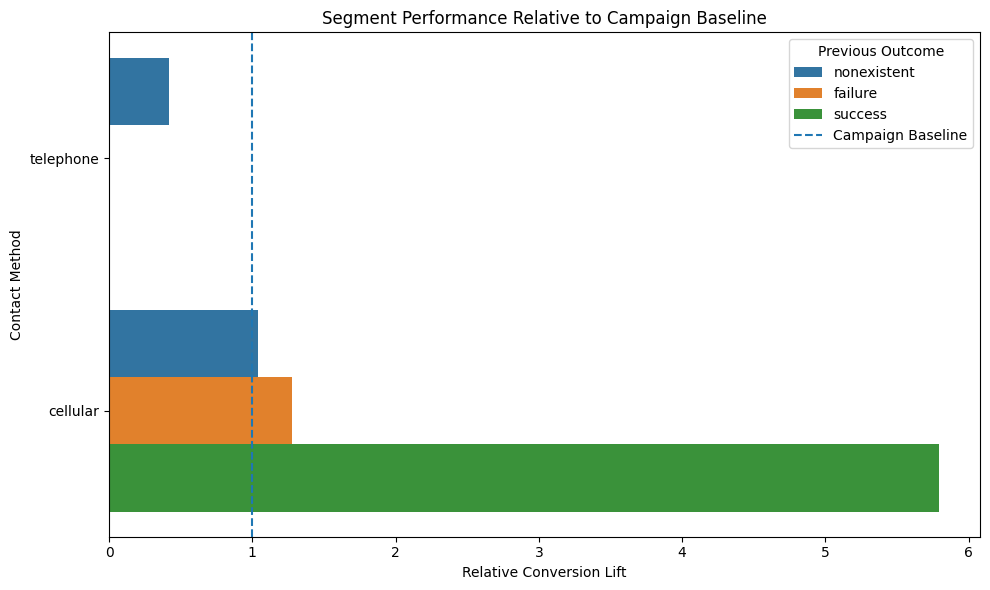

In [56]:
plot_data = segment_opportunities.sort_values(
    "relative_lift",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="relative_lift",
    y="contact",
    hue="poutcome"
)

plt.axvline(
    1,
    linestyle="--",
    label="Campaign Baseline"
)

plt.title(
    "Segment Performance Relative to Campaign Baseline"
)

plt.xlabel("Relative Conversion Lift")
plt.ylabel("Contact Method")

plt.legend(title="Previous Outcome")

plt.tight_layout()
plt.show()

In [57]:
opportunity_data = segment_opportunities.copy()

opportunity_data["volume_level"] = np.where(
    opportunity_data["customers"] >= opportunity_data["customers"].median(),
    "High Volume",
    "Low Volume"
)

opportunity_data["conversion_level"] = np.where(
    opportunity_data["conversion_rate"] >= overall_conversion_rate,
    "Above Baseline",
    "Below Baseline"
)

opportunity_data[
    [
        "poutcome",
        "contact",
        "customers",
        "conversion_rate",
        "relative_lift",
        "volume_level",
        "conversion_level"
    ]
]

,poutcome,contact,customers,conversion_rate,relative_lift,volume_level,conversion_level
0,success,cellular,1270,65.20,5.79,Low Volume,Above Baseline
1,failure,cellular,3952,14.45,1.28,Low Volume,Above Baseline
2,nonexistent,cellular,20913,11.73,1.04,High Volume,Above Baseline
3,nonexistent,telephone,14638,4.69,0.42,High Volume,Below Baseline


In [58]:
opportunity_data["segment_strategy"] = np.select(
    [
        (
            (opportunity_data["conversion_level"] == "Above Baseline") &
            (opportunity_data["volume_level"] == "High Volume")
        ),

        (
            (opportunity_data["conversion_level"] == "Above Baseline") &
            (opportunity_data["volume_level"] == "Low Volume")
        ),

        (
            (opportunity_data["conversion_level"] == "Below Baseline") &
            (opportunity_data["volume_level"] == "High Volume")
        )
    ],
    [
        "PRIORITY",
        "NICHE OPPORTUNITY",
        "OPTIMIZE"
    ],
    default="LOW PRIORITY"
)

opportunity_data[
    [
        "poutcome",
        "contact",
        "customers",
        "conversion_rate",
        "relative_lift",
        "segment_strategy"
    ]
]

,poutcome,contact,customers,conversion_rate,relative_lift,segment_strategy
0,success,cellular,1270,65.20,5.79,NICHE OPPORTUNITY
1,failure,cellular,3952,14.45,1.28,NICHE OPPORTUNITY
2,nonexistent,cellular,20913,11.73,1.04,PRIORITY
3,nonexistent,telephone,14638,4.69,0.42,OPTIMIZE


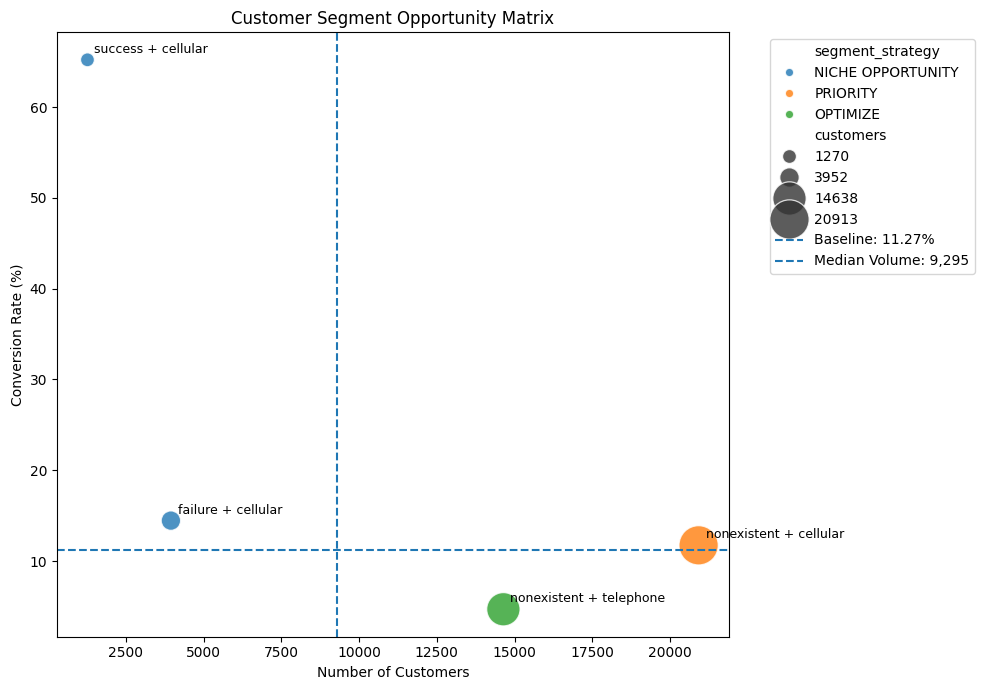

In [59]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=opportunity_data,
    x="customers",
    y="conversion_rate",
    size="customers",
    hue="segment_strategy",
    sizes=(100, 800),
    alpha=0.8
)

plt.axhline(
    overall_conversion_rate,
    linestyle="--",
    label=f"Baseline: {overall_conversion_rate:.2f}%"
)

median_customers = opportunity_data["customers"].median()

plt.axvline(
    median_customers,
    linestyle="--",
    label=f"Median Volume: {median_customers:,.0f}"
)

for _, row in opportunity_data.iterrows():
    plt.annotate(
        f"{row['poutcome']} + {row['contact']}",
        (row["customers"], row["conversion_rate"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(
    "Customer Segment Opportunity Matrix"
)

plt.xlabel("Number of Customers")
plt.ylabel("Conversion Rate (%)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [60]:
best_rate = opportunity_data["conversion_rate"].max()

print(f"Best segment conversion rate: {best_rate:.2f}%")

Best segment conversion rate: 65.20%


In [61]:
opportunity_data["potential_additional_conversions"] = (
    opportunity_data["customers"]
    * (best_rate - opportunity_data["conversion_rate"])
    / 100
).clip(lower=0)

opportunity_data["potential_additional_conversions"] = (
    opportunity_data["potential_additional_conversions"]
    .round()
    .astype(int)
)

In [62]:
opportunity_data[
    [
        "poutcome",
        "contact",
        "customers",
        "conversion_rate",
        "potential_additional_conversions",
        "segment_strategy"
    ]
].sort_values(
    "potential_additional_conversions",
    ascending=False
)

,poutcome,contact,customers,conversion_rate,potential_additional_conversions,segment_strategy
2,nonexistent,cellular,20913,11.73,11182,PRIORITY
3,nonexistent,telephone,14638,4.69,8857,OPTIMIZE
1,failure,cellular,3952,14.45,2006,NICHE OPPORTUNITY
0,success,cellular,1270,65.20,0,NICHE OPPORTUNITY


In [63]:
from statsmodels.stats.proportion import proportion_confint

In [64]:
confidence_data = opportunity_data.copy()

ci = confidence_data.apply(
    lambda row: proportion_confint(
        count=int(row["subscriptions"]),
        nobs=int(row["customers"]),
        alpha=0.05,
        method="wilson"
    ),
    axis=1
)

confidence_data["ci_lower"] = [
    interval[0] * 100
    for interval in ci
]

confidence_data["ci_upper"] = [
    interval[1] * 100
    for interval in ci
]

confidence_data["ci_lower"] = confidence_data["ci_lower"].round(2)
confidence_data["ci_upper"] = confidence_data["ci_upper"].round(2)

confidence_data

,poutcome,contact,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift,rank,opportunity,volume_level,conversion_level,segment_strategy,potential_additional_conversions,ci_lower,ci_upper
0,success,cellular,1270,828,65.20,3.08,53.93,5.79,1,High Opportunity,Low Volume,Above Baseline,NICHE OPPORTUNITY,0,62.53,67.77
1,failure,cellular,3952,571,14.45,9.60,3.18,1.28,2,Above Baseline,Low Volume,Above Baseline,NICHE OPPORTUNITY,2006,13.39,15.58
2,nonexistent,cellular,20913,2453,11.73,50.79,0.46,1.04,3,Above Baseline,High Volume,Above Baseline,PRIORITY,11182,11.30,12.17
3,nonexistent,telephone,14638,687,4.69,35.55,-6.58,0.42,4,Below Baseline,High Volume,Below Baseline,OPTIMIZE,8857,4.36,5.05


In [65]:
segment_validation = confidence_data[
    [
        "poutcome",
        "contact",
        "customers",
        "subscriptions",
        "conversion_rate",
        "ci_lower",
        "ci_upper",
        "relative_lift",
        "segment_strategy"
    ]
].sort_values(
    "conversion_rate",
    ascending=False
)

segment_validation

,poutcome,contact,customers,subscriptions,conversion_rate,ci_lower,ci_upper,relative_lift,segment_strategy
0,success,cellular,1270,828,65.20,62.53,67.77,5.79,NICHE OPPORTUNITY
1,failure,cellular,3952,571,14.45,13.39,15.58,1.28,NICHE OPPORTUNITY
2,nonexistent,cellular,20913,2453,11.73,11.30,12.17,1.04,PRIORITY
3,nonexistent,telephone,14638,687,4.69,4.36,5.05,0.42,OPTIMIZE


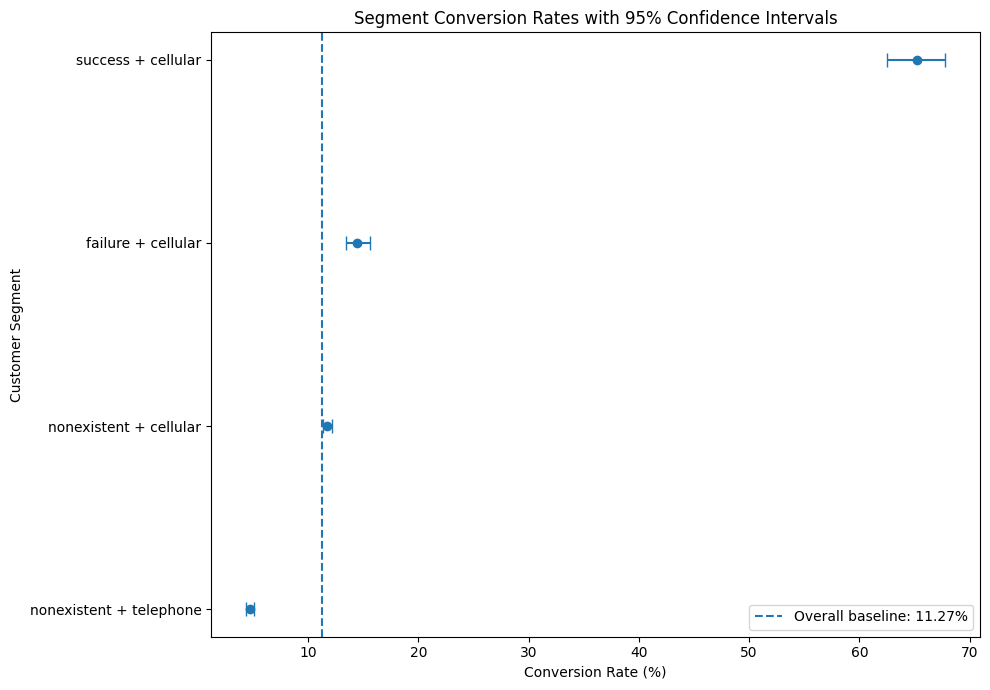

In [66]:
plot_data = segment_validation.sort_values(
    "conversion_rate"
).copy()

y_positions = np.arange(len(plot_data))

plt.figure(figsize=(10, 7))

plt.errorbar(
    plot_data["conversion_rate"],
    y_positions,
    xerr=[
        plot_data["conversion_rate"] - plot_data["ci_lower"],
        plot_data["ci_upper"] - plot_data["conversion_rate"]
    ],
    fmt="o",
    capsize=5
)

plt.axvline(
    overall_conversion_rate,
    linestyle="--",
    label=f"Overall baseline: {overall_conversion_rate:.2f}%"
)

plt.yticks(
    y_positions,
    plot_data["poutcome"] + " + " + plot_data["contact"]
)

plt.xlabel("Conversion Rate (%)")
plt.ylabel("Customer Segment")

plt.title(
    "Segment Conversion Rates with 95% Confidence Intervals"
)

plt.legend()
plt.tight_layout()
plt.show()

In [67]:
robust_opportunities = segment_validation[
    (
        (segment_validation["customers"] >= MIN_SEGMENT_SIZE) &
        (segment_validation["conversion_rate"] > overall_conversion_rate)
    )
].copy()

robust_opportunities

,poutcome,contact,customers,subscriptions,conversion_rate,ci_lower,ci_upper,relative_lift,segment_strategy
0,success,cellular,1270,828,65.20,62.53,67.77,5.79,NICHE OPPORTUNITY
1,failure,cellular,3952,571,14.45,13.39,15.58,1.28,NICHE OPPORTUNITY
2,nonexistent,cellular,20913,2453,11.73,11.30,12.17,1.04,PRIORITY


In [68]:
robust_opportunities = (
    robust_opportunities
    .sort_values(
        ["relative_lift", "customers"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

robust_opportunities["priority_rank"] = (
    robust_opportunities.index + 1
)

robust_opportunities

,poutcome,contact,customers,subscriptions,conversion_rate,ci_lower,ci_upper,relative_lift,segment_strategy,priority_rank
0,success,cellular,1270,828,65.20,62.53,67.77,5.79,NICHE OPPORTUNITY,1
1,failure,cellular,3952,571,14.45,13.39,15.58,1.28,NICHE OPPORTUNITY,2
2,nonexistent,cellular,20913,2453,11.73,11.30,12.17,1.04,PRIORITY,3


In [69]:
# Create campaign frequency groups

campaign_bins = [0, 1, 2, 3, 5, np.inf]

campaign_labels = [
    "1 contact",
    "2 contacts",
    "3 contacts",
    "4-5 contacts",
    "6+ contacts"
]

df_clean["campaign_group"] = pd.cut(
    df_clean["campaign"],
    bins=campaign_bins,
    labels=campaign_labels,
    include_lowest=True
)

In [70]:
# Check campaign frequency groups

df_clean[
    ["campaign", "campaign_group"]
].head(10)

,campaign,campaign_group
0,1,1 contact
1,1,1 contact
2,1,1 contact
3,1,1 contact
4,1,1 contact
5,1,1 contact
6,1,1 contact
7,1,1 contact
8,1,1 contact
9,1,1 contact


In [71]:
df_clean["campaign_group"].value_counts().sort_index()

,count
campaign_group,
1 contact,17634
2 contacts,10568
3 contacts,5340
4-5 contacts,4249
6+ contacts,3385


In [72]:
# Campaign frequency analysis

campaign_analysis = (
    df_clean
    .groupby(
        "campaign_group",
        observed=True
    )
    .agg(
        customers=("subscribed_flag", "size"),
        subscriptions=("subscribed_flag", "sum")
    )
    .reset_index()
)

campaign_analysis["conversion_rate"] = (
    campaign_analysis["subscriptions"]
    / campaign_analysis["customers"]
    * 100
).round(2)

campaign_analysis["customer_share"] = (
    campaign_analysis["customers"]
    / len(df_clean)
    * 100
).round(2)

campaign_analysis["lift_vs_baseline"] = (
    campaign_analysis["conversion_rate"]
    - overall_conversion_rate
).round(2)

campaign_analysis["relative_lift"] = (
    campaign_analysis["conversion_rate"]
    / overall_conversion_rate
).round(2)

campaign_analysis

,campaign_group,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift
0,1 contact,17634,2299,13.04,42.83,1.77,1.16
1,2 contacts,10568,1211,11.46,25.67,0.19,1.02
2,3 contacts,5340,574,10.75,12.97,-0.52,0.95
3,4-5 contacts,4249,369,8.68,10.32,-2.59,0.77
4,6+ contacts,3385,186,5.49,8.22,-5.78,0.49


In [73]:
# Measure change in conversion between contact groups

campaign_analysis["marginal_change"] = (
    campaign_analysis["conversion_rate"]
    .diff()
    .round(2)
)

campaign_analysis

,campaign_group,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift,marginal_change
0,1 contact,17634,2299,13.04,42.83,1.77,1.16,NaN
1,2 contacts,10568,1211,11.46,25.67,0.19,1.02,-1.58
2,3 contacts,5340,574,10.75,12.97,-0.52,0.95,-0.71
3,4-5 contacts,4249,369,8.68,10.32,-2.59,0.77,-2.07
4,6+ contacts,3385,186,5.49,8.22,-5.78,0.49,-3.19


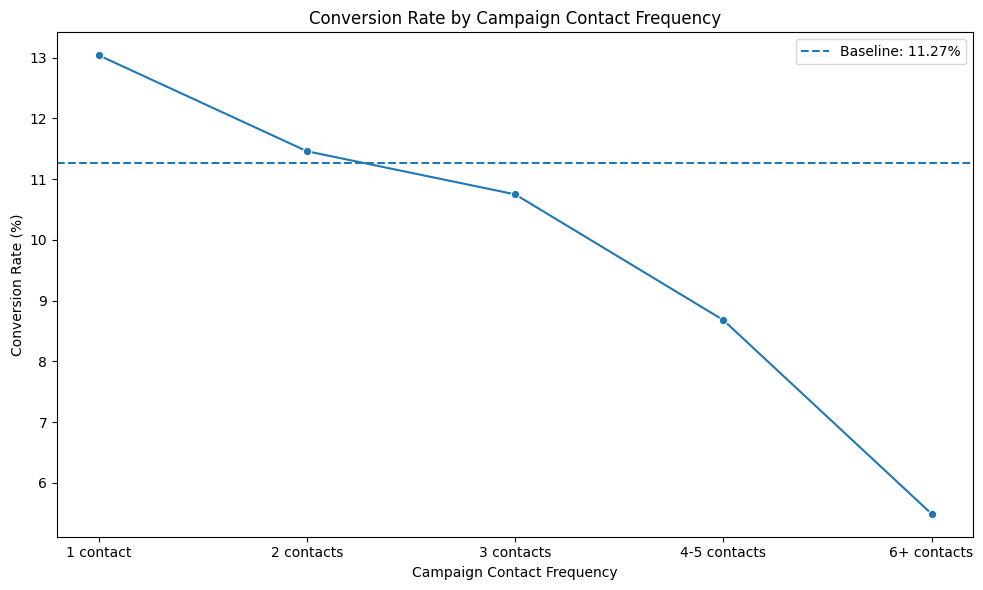

In [74]:
# Conversion rate by campaign frequency

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=campaign_analysis,
    x="campaign_group",
    y="conversion_rate",
    marker="o"
)

plt.axhline(
    overall_conversion_rate,
    linestyle="--",
    label=f"Baseline: {overall_conversion_rate:.2f}%"
)

plt.title(
    "Conversion Rate by Campaign Contact Frequency"
)

plt.xlabel("Campaign Contact Frequency")
plt.ylabel("Conversion Rate (%)")

plt.legend()
plt.tight_layout()
plt.show()

In [75]:
# Identify the highest-converting campaign group

best_campaign_group = campaign_analysis.loc[
    campaign_analysis["conversion_rate"].idxmax()
]

best_campaign_group

,0
campaign_group,1 contact
customers,17634
subscriptions,2299
conversion_rate,13.04
customer_share,42.83
lift_vs_baseline,1.77
relative_lift,1.16
marginal_change,NaN


In [76]:
campaign_sql = """
SELECT
    CASE
        WHEN campaign = 1 THEN '1 contact'
        WHEN campaign = 2 THEN '2 contacts'
        WHEN campaign = 3 THEN '3 contacts'
        WHEN campaign BETWEEN 4 AND 5 THEN '4-5 contacts'
        ELSE '6+ contacts'
    END AS campaign_group,

    COUNT(*) AS customers,

    SUM(
        CASE
            WHEN y = 'yes' THEN 1
            ELSE 0
        END
    ) AS subscriptions,

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN y = 'yes' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS conversion_rate

FROM customers_clean

GROUP BY campaign_group

ORDER BY
    CASE campaign_group
        WHEN '1 contact' THEN 1
        WHEN '2 contacts' THEN 2
        WHEN '3 contacts' THEN 3
        WHEN '4-5 contacts' THEN 4
        WHEN '6+ contacts' THEN 5
    END;
"""

campaign_sql_result = pd.read_sql_query(
    campaign_sql,
    conn
)

campaign_sql_result

,campaign_group,customers,subscriptions,conversion_rate
0,1 contact,17634,2299,13.04
1,2 contacts,10568,1211,11.46
2,3 contacts,5340,574,10.75
3,4-5 contacts,4249,369,8.68
4,6+ contacts,3385,186,5.49


In [77]:
# Define dimensions for multi-factor segmentation

segment_columns = [
    "job",
    "poutcome"
]

segment_columns

['job', 'poutcome']

In [78]:
multi_segment_analysis = (
    df_clean
    .groupby(
        segment_columns,
        dropna=False
    )
    .agg(
        customers=("subscribed_flag", "size"),
        subscriptions=("subscribed_flag", "sum")
    )
    .reset_index()
)

multi_segment_analysis

,job,poutcome,customers,subscriptions
0,admin.,failure,1091,165
1,admin.,nonexistent,8900,900
2,admin.,success,428,286
3,blue-collar,failure,886,70
4,blue-collar,nonexistent,8248,509
5,blue-collar,success,119,59
6,entrepreneur,failure,154,11
7,entrepreneur,nonexistent,1277,102
8,entrepreneur,success,25,11
9,housemaid,failure,74,12


In [79]:
multi_segment_analysis["conversion_rate"] = (
    multi_segment_analysis["subscriptions"]
    / multi_segment_analysis["customers"]
    * 100
).round(2)

multi_segment_analysis

,job,poutcome,customers,subscriptions,conversion_rate
0,admin.,failure,1091,165,15.12
1,admin.,nonexistent,8900,900,10.11
2,admin.,success,428,286,66.82
3,blue-collar,failure,886,70,7.90
4,blue-collar,nonexistent,8248,509,6.17
5,blue-collar,success,119,59,49.58
6,entrepreneur,failure,154,11,7.14
7,entrepreneur,nonexistent,1277,102,7.99
8,entrepreneur,success,25,11,44.00
9,housemaid,failure,74,12,16.22


In [80]:
multi_segment_analysis["customer_share"] = (
    multi_segment_analysis["customers"]
    / len(df_clean)
    * 100
).round(2)

multi_segment_analysis

,job,poutcome,customers,subscriptions,conversion_rate,customer_share
0,admin.,failure,1091,165,15.12,2.65
1,admin.,nonexistent,8900,900,10.11,21.61
2,admin.,success,428,286,66.82,1.04
3,blue-collar,failure,886,70,7.90,2.15
4,blue-collar,nonexistent,8248,509,6.17,20.03
5,blue-collar,success,119,59,49.58,0.29
6,entrepreneur,failure,154,11,7.14,0.37
7,entrepreneur,nonexistent,1277,102,7.99,3.10
8,entrepreneur,success,25,11,44.00,0.06
9,housemaid,failure,74,12,16.22,0.18


In [81]:
multi_segment_analysis["lift_vs_baseline"] = (
    multi_segment_analysis["conversion_rate"]
    - overall_conversion_rate
).round(2)

multi_segment_analysis["relative_lift"] = (
    multi_segment_analysis["conversion_rate"]
    / overall_conversion_rate
).round(2)

multi_segment_analysis

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift
0,admin.,failure,1091,165,15.12,2.65,3.85,1.34
1,admin.,nonexistent,8900,900,10.11,21.61,-1.16,0.90
2,admin.,success,428,286,66.82,1.04,55.55,5.93
3,blue-collar,failure,886,70,7.90,2.15,-3.37,0.70
4,blue-collar,nonexistent,8248,509,6.17,20.03,-5.10,0.55
5,blue-collar,success,119,59,49.58,0.29,38.31,4.40
6,entrepreneur,failure,154,11,7.14,0.37,-4.13,0.63
7,entrepreneur,nonexistent,1277,102,7.99,3.10,-3.28,0.71
8,entrepreneur,success,25,11,44.00,0.06,32.73,3.91
9,housemaid,failure,74,12,16.22,0.18,4.95,1.44


In [82]:
MIN_SEGMENT_SIZE = 300

multi_segment_opportunities = (
    multi_segment_analysis[
        multi_segment_analysis["customers"] >= MIN_SEGMENT_SIZE
    ]
    .copy()
)

multi_segment_opportunities

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift
0,admin.,failure,1091,165,15.12,2.65,3.85,1.34
1,admin.,nonexistent,8900,900,10.11,21.61,-1.16,0.90
2,admin.,success,428,286,66.82,1.04,55.55,5.93
3,blue-collar,failure,886,70,7.90,2.15,-3.37,0.70
4,blue-collar,nonexistent,8248,509,6.17,20.03,-5.10,0.55
7,entrepreneur,nonexistent,1277,102,7.99,3.10,-3.28,0.71
10,housemaid,nonexistent,948,67,7.07,2.30,-4.20,0.63
12,management,failure,331,43,12.99,0.80,1.72,1.15
13,management,nonexistent,2498,219,8.77,6.07,-2.50,0.78
16,retired,nonexistent,1330,254,19.10,3.23,7.83,1.70


In [83]:
multi_segment_opportunities = (
    multi_segment_opportunities
    .sort_values(
        ["conversion_rate", "customers"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

multi_segment_opportunities["rank"] = (
    multi_segment_opportunities.index + 1
)

multi_segment_opportunities

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift,rank
0,admin.,success,428,286,66.82,1.04,55.55,5.93,1
1,student,nonexistent,594,148,24.92,1.44,13.65,2.21,2
2,retired,nonexistent,1330,254,19.10,3.23,7.83,1.70,3
3,technician,failure,618,110,17.80,1.50,6.53,1.58,4
4,admin.,failure,1091,165,15.12,2.65,3.85,1.34,5
5,management,failure,331,43,12.99,0.80,1.72,1.15,6
6,admin.,nonexistent,8900,900,10.11,21.61,-1.16,0.90,7
7,unemployed,nonexistent,858,84,9.79,2.08,-1.48,0.87,8
8,services,failure,448,42,9.38,1.09,-1.89,0.83,9
9,self-employed,nonexistent,1246,115,9.23,3.03,-2.04,0.82,10


In [84]:
# Calculate a business opportunity score

multi_segment_opportunities["volume_score"] = (
    multi_segment_opportunities["customers"]
    / multi_segment_opportunities["customers"].max()
)

multi_segment_opportunities["lift_score"] = (
    multi_segment_opportunities["relative_lift"]
    / multi_segment_opportunities["relative_lift"].max()
)

multi_segment_opportunities["opportunity_score"] = (
    0.5 * multi_segment_opportunities["volume_score"]
    + 0.5 * multi_segment_opportunities["lift_score"]
).round(3)

multi_segment_opportunities

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift,rank,volume_score,lift_score,opportunity_score
0,admin.,success,428,286,66.82,1.04,55.55,5.93,1,0.048090,1.000000,0.524
1,student,nonexistent,594,148,24.92,1.44,13.65,2.21,2,0.066742,0.372681,0.220
2,retired,nonexistent,1330,254,19.10,3.23,7.83,1.70,3,0.149438,0.286678,0.218
3,technician,failure,618,110,17.80,1.50,6.53,1.58,4,0.069438,0.266442,0.168
4,admin.,failure,1091,165,15.12,2.65,3.85,1.34,5,0.122584,0.225970,0.174
5,management,failure,331,43,12.99,0.80,1.72,1.15,6,0.037191,0.193929,0.116
6,admin.,nonexistent,8900,900,10.11,21.61,-1.16,0.90,7,1.000000,0.151771,0.576
7,unemployed,nonexistent,858,84,9.79,2.08,-1.48,0.87,8,0.096404,0.146712,0.122
8,services,failure,448,42,9.38,1.09,-1.89,0.83,9,0.050337,0.139966,0.095
9,self-employed,nonexistent,1246,115,9.23,3.03,-2.04,0.82,10,0.140000,0.138280,0.139


In [85]:
# Rank segments by overall opportunity

multi_segment_opportunities = (
    multi_segment_opportunities
    .sort_values(
        "opportunity_score",
        ascending=False
    )
    .reset_index(drop=True)
)

multi_segment_opportunities["priority_rank"] = (
    multi_segment_opportunities.index + 1
)

multi_segment_opportunities[
    [
        "priority_rank",
        "job",
        "poutcome",
        "customers",
        "conversion_rate",
        "relative_lift",
        "opportunity_score"
    ]
]

,priority_rank,job,poutcome,customers,conversion_rate,relative_lift,opportunity_score
0,1,admin.,nonexistent,8900,10.11,0.90,0.576
1,2,admin.,success,428,66.82,5.93,0.524
2,3,blue-collar,nonexistent,8248,6.17,0.55,0.510
3,4,technician,nonexistent,5910,8.14,0.72,0.393
4,5,services,nonexistent,3449,6.93,0.62,0.246
5,6,student,nonexistent,594,24.92,2.21,0.220
6,7,retired,nonexistent,1330,19.10,1.70,0.218
7,8,management,nonexistent,2498,8.77,0.78,0.206
8,9,admin.,failure,1091,15.12,1.34,0.174
9,10,technician,failure,618,17.80,1.58,0.168


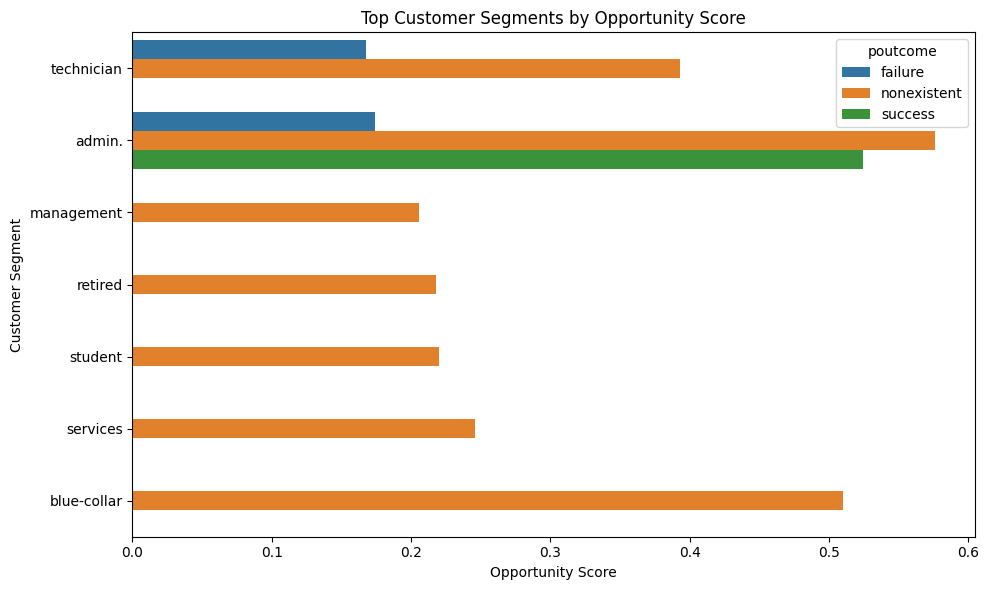

In [86]:
# Top segment opportunities

top_segments = (
    multi_segment_opportunities
    .head(10)
    .sort_values("opportunity_score")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_segments,
    x="opportunity_score",
    y="job",
    hue="poutcome"
)

plt.title("Top Customer Segments by Opportunity Score")

plt.xlabel("Opportunity Score")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [87]:
from statsmodels.stats.proportion import proportion_confint

In [88]:
# Calculate 95% Wilson confidence intervals

ci = multi_segment_opportunities.apply(
    lambda row: proportion_confint(
        count=int(row["subscriptions"]),
        nobs=int(row["customers"]),
        alpha=0.05,
        method="wilson"
    ),
    axis=1
)

multi_segment_opportunities["ci_lower"] = [
    interval[0] * 100
    for interval in ci
]

multi_segment_opportunities["ci_upper"] = [
    interval[1] * 100
    for interval in ci
]

multi_segment_opportunities["ci_lower"] = (
    multi_segment_opportunities["ci_lower"].round(2)
)

multi_segment_opportunities["ci_upper"] = (
    multi_segment_opportunities["ci_upper"].round(2)
)

multi_segment_opportunities

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,lift_vs_baseline,relative_lift,rank,volume_score,lift_score,opportunity_score,priority_rank,ci_lower,ci_upper
0,admin.,nonexistent,8900,900,10.11,21.61,-1.16,0.90,7,1.000000,0.151771,0.576,1,9.50,10.76
1,admin.,success,428,286,66.82,1.04,55.55,5.93,1,0.048090,1.000000,0.524,2,62.23,71.12
2,blue-collar,nonexistent,8248,509,6.17,20.03,-5.10,0.55,17,0.926742,0.092749,0.510,3,5.67,6.71
3,technician,nonexistent,5910,481,8.14,14.35,-3.13,0.72,12,0.664045,0.121417,0.393,4,7.47,8.86
4,services,nonexistent,3449,239,6.93,8.38,-4.34,0.62,16,0.387528,0.104553,0.246,5,6.13,7.83
5,student,nonexistent,594,148,24.92,1.44,13.65,2.21,2,0.066742,0.372681,0.220,6,21.61,28.55
6,retired,nonexistent,1330,254,19.10,3.23,7.83,1.70,3,0.149438,0.286678,0.218,7,17.08,21.30
7,management,nonexistent,2498,219,8.77,6.07,-2.50,0.78,11,0.280674,0.131535,0.206,8,7.72,9.94
8,admin.,failure,1091,165,15.12,2.65,3.85,1.34,5,0.122584,0.225970,0.174,9,13.12,17.37
9,technician,failure,618,110,17.80,1.50,6.53,1.58,4,0.069438,0.266442,0.168,10,14.99,21.01


In [89]:
final_segment_analysis = (
    multi_segment_opportunities[
        [
            "priority_rank",
            "job",
            "poutcome",
            "customers",
            "subscriptions",
            "conversion_rate",
            "ci_lower",
            "ci_upper",
            "relative_lift",
            "opportunity_score"
        ]
    ]
    .sort_values("priority_rank")
)

final_segment_analysis

,priority_rank,job,poutcome,customers,subscriptions,conversion_rate,ci_lower,ci_upper,relative_lift,opportunity_score
0,1,admin.,nonexistent,8900,900,10.11,9.50,10.76,0.90,0.576
1,2,admin.,success,428,286,66.82,62.23,71.12,5.93,0.524
2,3,blue-collar,nonexistent,8248,509,6.17,5.67,6.71,0.55,0.510
3,4,technician,nonexistent,5910,481,8.14,7.47,8.86,0.72,0.393
4,5,services,nonexistent,3449,239,6.93,6.13,7.83,0.62,0.246
5,6,student,nonexistent,594,148,24.92,21.61,28.55,2.21,0.220
6,7,retired,nonexistent,1330,254,19.10,17.08,21.30,1.70,0.218
7,8,management,nonexistent,2498,219,8.77,7.72,9.94,0.78,0.206
8,9,admin.,failure,1091,165,15.12,13.12,17.37,1.34,0.174
9,10,technician,failure,618,110,17.80,14.99,21.01,1.58,0.168


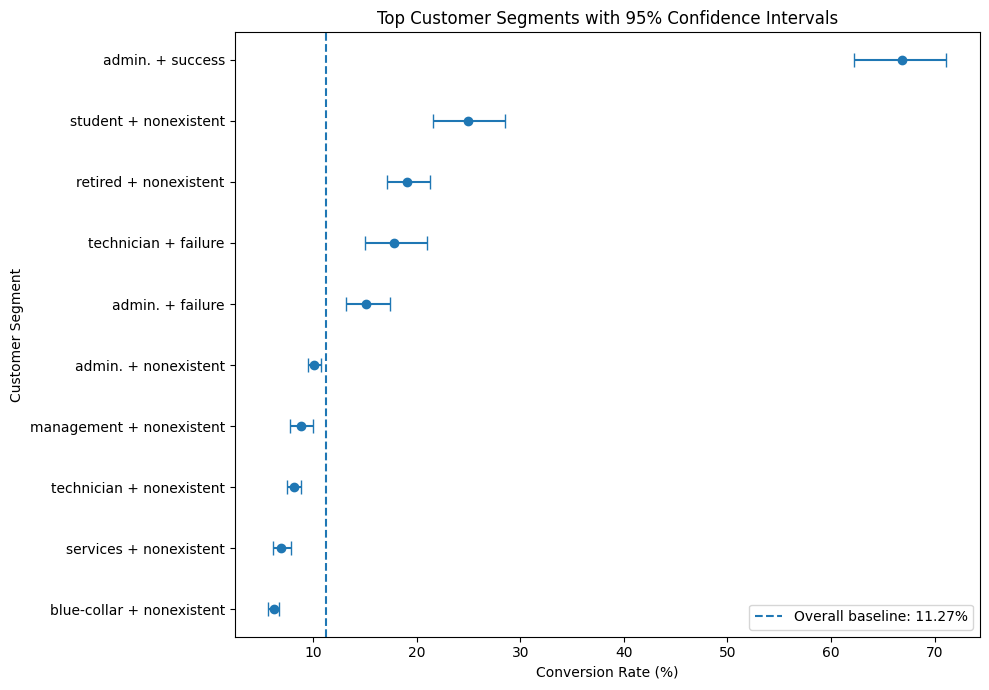

In [90]:
plot_data = (
    final_segment_analysis
    .head(10)
    .sort_values("conversion_rate")
)

y = np.arange(len(plot_data))

plt.figure(figsize=(10, 7))

plt.errorbar(
    plot_data["conversion_rate"],
    y,
    xerr=[
        plot_data["conversion_rate"] - plot_data["ci_lower"],
        plot_data["ci_upper"] - plot_data["conversion_rate"]
    ],
    fmt="o",
    capsize=5
)

plt.axvline(
    overall_conversion_rate,
    linestyle="--",
    label=f"Overall baseline: {overall_conversion_rate:.2f}%"
)

plt.yticks(
    y,
    plot_data["job"] + " + " + plot_data["poutcome"]
)

plt.xlabel("Conversion Rate (%)")
plt.ylabel("Customer Segment")

plt.title(
    "Top Customer Segments with 95% Confidence Intervals"
)

plt.legend()
plt.tight_layout()
plt.show()

In [91]:
# Check available SQLite tables

tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

tables

,name
0,customers_raw
1,customers_clean


In [92]:
# Inspect the SQLite table structure

table_info = pd.read_sql_query(
    """
    PRAGMA table_info(customers_clean);
    """,
    conn
)

table_info

,cid,name,type,notnull,dflt_value,pk
0,0,age,INTEGER,0,None,0
1,1,job,TEXT,0,None,0
2,2,marital,TEXT,0,None,0
3,3,education,TEXT,0,None,0
4,4,default,TEXT,0,None,0
5,5,housing,TEXT,0,None,0
6,6,loan,TEXT,0,None,0
7,7,contact,TEXT,0,None,0
8,8,month,TEXT,0,None,0
9,9,day_of_week,TEXT,0,None,0


In [93]:
segment_sql = """
WITH segment_summary AS (

    SELECT
        job,
        poutcome,

        COUNT(*) AS customers,

        SUM(
            CASE
                WHEN subscribed_flag = 1 THEN 1
                ELSE 0
            END
        ) AS subscriptions

    FROM customers_clean

    GROUP BY
        job,
        poutcome
)

SELECT
    job,
    poutcome,
    customers,
    subscriptions,

    ROUND(
        100.0 * subscriptions / customers,
        2
    ) AS conversion_rate

FROM segment_summary

ORDER BY
    conversion_rate DESC;
"""

segment_sql_result = pd.read_sql_query(
    segment_sql,
    conn
)

segment_sql_result

,job,poutcome,customers,subscriptions,conversion_rate
0,retired,success,158,117,74.05
1,student,success,118,84,71.19
2,housemaid,success,38,27,71.05
3,management,success,95,66,69.47
4,admin.,success,428,286,66.82
5,unemployed,success,62,41,66.13
6,technician,success,211,139,65.88
7,services,success,70,42,60.00
8,self-employed,success,30,16,53.33
9,unknown,failure,18,9,50.00


In [94]:
segment_sql_filtered = """
WITH segment_summary AS (

    SELECT
        job,
        poutcome,

        COUNT(*) AS customers,

        SUM(
            CASE
                WHEN subscribed_flag = 1 THEN 1
                ELSE 0
            END
        ) AS subscriptions

    FROM customers_clean

    GROUP BY
        job,
        poutcome

    HAVING COUNT(*) >= 300
)

SELECT
    job,
    poutcome,
    customers,
    subscriptions,

    ROUND(
        100.0 * subscriptions / customers,
        2
    ) AS conversion_rate

FROM segment_summary

ORDER BY
    conversion_rate DESC;
"""

segment_sql_filtered_result = pd.read_sql_query(
    segment_sql_filtered,
    conn
)

segment_sql_filtered_result


,job,poutcome,customers,subscriptions,conversion_rate
0,admin.,success,428,286,66.82
1,student,nonexistent,594,148,24.92
2,retired,nonexistent,1330,254,19.10
3,technician,failure,618,110,17.80
4,admin.,failure,1091,165,15.12
5,management,failure,331,43,12.99
6,admin.,nonexistent,8900,900,10.11
7,unemployed,nonexistent,858,84,9.79
8,services,failure,448,42,9.38
9,self-employed,nonexistent,1246,115,9.23


In [95]:
ranked_segments_sql = """
WITH segment_summary AS (

    SELECT
        job,
        poutcome,

        COUNT(*) AS customers,

        SUM(
            CASE
                WHEN subscribed_flag = 1 THEN 1
                ELSE 0
            END
        ) AS subscriptions

    FROM customers_clean

    GROUP BY
        job,
        poutcome

    HAVING COUNT(*) >= 300
),

segment_metrics AS (

    SELECT
        job,
        poutcome,
        customers,
        subscriptions,

        ROUND(
            100.0 * subscriptions / customers,
            2
        ) AS conversion_rate

    FROM segment_summary
),

ranked_segments AS (

    SELECT
        *,

        RANK() OVER (
            ORDER BY conversion_rate DESC
        ) AS conversion_rank

    FROM segment_metrics
)

SELECT
    conversion_rank,
    job,
    poutcome,
    customers,
    subscriptions,
    conversion_rate

FROM ranked_segments

ORDER BY conversion_rank;
"""

ranked_segments_result = pd.read_sql_query(
    ranked_segments_sql,
    conn
)

ranked_segments_result

,conversion_rank,job,poutcome,customers,subscriptions,conversion_rate
0,1,admin.,success,428,286,66.82
1,2,student,nonexistent,594,148,24.92
2,3,retired,nonexistent,1330,254,19.10
3,4,technician,failure,618,110,17.80
4,5,admin.,failure,1091,165,15.12
5,6,management,failure,331,43,12.99
6,7,admin.,nonexistent,8900,900,10.11
7,8,unemployed,nonexistent,858,84,9.79
8,9,services,failure,448,42,9.38
9,10,self-employed,nonexistent,1246,115,9.23


In [96]:
lift_sql = """
WITH segment_summary AS (

    SELECT
        job,
        poutcome,

        COUNT(*) AS customers,

        SUM(
            CASE
                WHEN subscribed_flag = 1 THEN 1
                ELSE 0
            END
        ) AS subscriptions

    FROM customers_clean

    GROUP BY
        job,
        poutcome

    HAVING COUNT(*) >= 300
),

segment_metrics AS (

    SELECT
        job,
        poutcome,
        customers,
        subscriptions,

        100.0 * subscriptions / customers
            AS conversion_rate

    FROM segment_summary
),

overall_metrics AS (

    SELECT
        100.0 * SUM(subscribed_flag)
        / COUNT(*) AS overall_conversion_rate

    FROM customers_clean
)

SELECT
    s.job,
    s.poutcome,
    s.customers,
    s.subscriptions,

    ROUND(
        s.conversion_rate,
        2
    ) AS conversion_rate,

    ROUND(
        s.conversion_rate
        - o.overall_conversion_rate,
        2
    ) AS lift_vs_baseline,

    ROUND(
        s.conversion_rate
        / o.overall_conversion_rate,
        2
    ) AS relative_lift

FROM segment_metrics s

CROSS JOIN overall_metrics o

ORDER BY
    relative_lift DESC;
"""

lift_sql_result = pd.read_sql_query(
    lift_sql,
    conn
)

lift_sql_result

,job,poutcome,customers,subscriptions,conversion_rate,lift_vs_baseline,relative_lift
0,admin.,success,428,286,66.82,55.56,5.93
1,student,nonexistent,594,148,24.92,13.65,2.21
2,retired,nonexistent,1330,254,19.10,7.83,1.70
3,technician,failure,618,110,17.80,6.53,1.58
4,admin.,failure,1091,165,15.12,3.86,1.34
5,management,failure,331,43,12.99,1.72,1.15
6,admin.,nonexistent,8900,900,10.11,-1.15,0.90
7,unemployed,nonexistent,858,84,9.79,-1.48,0.87
8,services,failure,448,42,9.38,-1.89,0.83
9,self-employed,nonexistent,1246,115,9.23,-2.04,0.82


In [97]:
top_segments_sql = """
WITH segment_summary AS (

    SELECT
        job,
        poutcome,

        COUNT(*) AS customers,

        SUM(subscribed_flag) AS subscriptions

    FROM customers_clean

    GROUP BY
        job,
        poutcome

    HAVING COUNT(*) >= 300
),

segment_metrics AS (

    SELECT
        job,
        poutcome,
        customers,
        subscriptions,

        100.0 * subscriptions / customers
            AS conversion_rate

    FROM segment_summary
),

ranked_segments AS (

    SELECT
        *,

        DENSE_RANK() OVER (
            PARTITION BY poutcome
            ORDER BY conversion_rate DESC
        ) AS segment_rank

    FROM segment_metrics
)

SELECT
    segment_rank,
    poutcome,
    job,
    customers,
    subscriptions,

    ROUND(
        conversion_rate,
        2
    ) AS conversion_rate

FROM ranked_segments

WHERE segment_rank <= 3

ORDER BY
    poutcome,
    segment_rank;
"""

top_segments_result = pd.read_sql_query(
    top_segments_sql,
    conn
)

top_segments_result

,segment_rank,poutcome,job,customers,subscriptions,conversion_rate
0,1,failure,technician,618,110,17.80
1,2,failure,admin.,1091,165,15.12
2,3,failure,management,331,43,12.99
3,1,nonexistent,student,594,148,24.92
4,2,nonexistent,retired,1330,254,19.10
5,3,nonexistent,admin.,8900,900,10.11
6,1,success,admin.,428,286,66.82


In [98]:
best_by_outcome = top_segments_result[
    top_segments_result["segment_rank"] == 1
].copy()

best_by_outcome

,segment_rank,poutcome,job,customers,subscriptions,conversion_rate
0,1,failure,technician,618,110,17.80
3,1,nonexistent,student,594,148,24.92
6,1,success,admin.,428,286,66.82


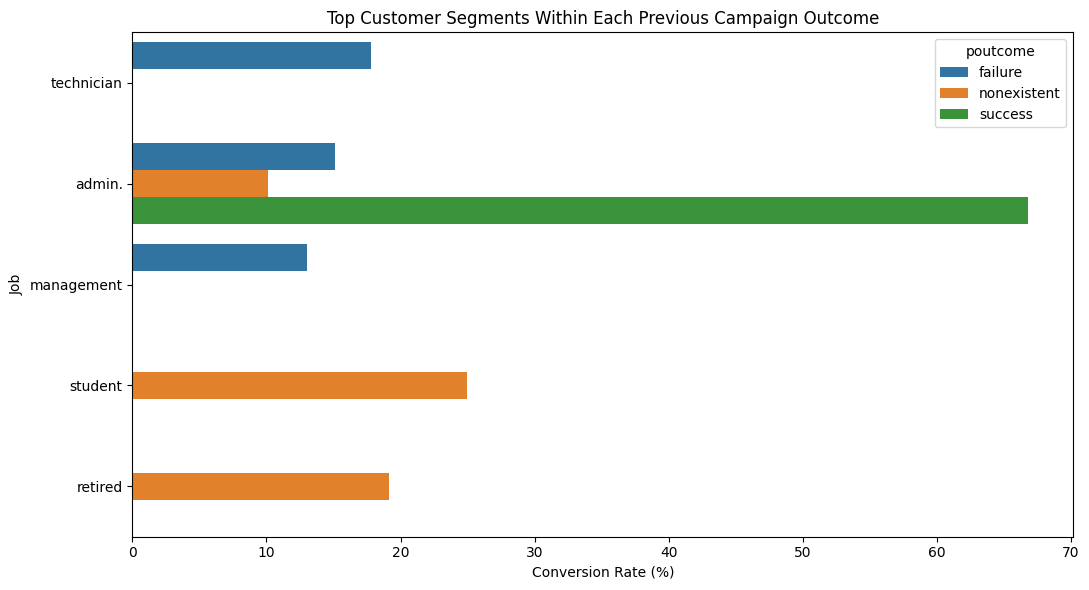

In [99]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_segments_result,
    x="conversion_rate",
    y="job",
    hue="poutcome"
)

plt.title(
    "Top Customer Segments Within Each Previous Campaign Outcome"
)

plt.xlabel("Conversion Rate (%)")
plt.ylabel("Job")

plt.tight_layout()
plt.show()

In [100]:
campaign_segment_sql = """
WITH campaign_segments AS (

    SELECT
        job,
        poutcome,

        CASE
            WHEN campaign = 1 THEN '1 contact'
            WHEN campaign = 2 THEN '2 contacts'
            WHEN campaign = 3 THEN '3 contacts'
            WHEN campaign BETWEEN 4 AND 5 THEN '4-5 contacts'
            ELSE '6+ contacts'
        END AS campaign_group,

        COUNT(*) AS customers,

        SUM(subscribed_flag) AS subscriptions

    FROM customers_clean

    GROUP BY
        job,
        poutcome,
        campaign_group

    HAVING COUNT(*) >= 100
),

segment_metrics AS (

    SELECT
        job,
        poutcome,
        campaign_group,
        customers,
        subscriptions,

        100.0 * subscriptions / customers
            AS conversion_rate

    FROM campaign_segments
)

SELECT
    job,
    poutcome,
    campaign_group,
    customers,
    subscriptions,

    ROUND(
        conversion_rate,
        2
    ) AS conversion_rate

FROM segment_metrics

ORDER BY
    conversion_rate DESC;
"""

campaign_segment_result = pd.read_sql_query(
    campaign_segment_sql,
    conn
)

campaign_segment_result

,job,poutcome,campaign_group,customers,subscriptions,conversion_rate
0,admin.,success,1 contact,234,164,70.09
1,technician,success,1 contact,114,74,64.91
2,admin.,success,2 contacts,118,76,64.41
3,student,nonexistent,2 contacts,143,41,28.67
4,retired,failure,1 contact,116,33,28.45
...,...,...,...,...,...,...
58,management,nonexistent,4-5 contacts,260,14,5.38
59,blue-collar,failure,2 contacts,244,13,5.33
60,blue-collar,nonexistent,4-5 contacts,860,44,5.12
61,technician,nonexistent,6+ contacts,549,26,4.74


In [101]:
ranked_campaign_segments_sql = """
WITH campaign_segments AS (

    SELECT
        job,
        poutcome,

        CASE
            WHEN campaign = 1 THEN '1 contact'
            WHEN campaign = 2 THEN '2 contacts'
            WHEN campaign = 3 THEN '3 contacts'
            WHEN campaign BETWEEN 4 AND 5 THEN '4-5 contacts'
            ELSE '6+ contacts'
        END AS campaign_group,

        COUNT(*) AS customers,

        SUM(subscribed_flag) AS subscriptions

    FROM customers_clean

    GROUP BY
        job,
        poutcome,
        campaign_group

    HAVING COUNT(*) >= 100
),

segment_metrics AS (

    SELECT
        job,
        poutcome,
        campaign_group,
        customers,
        subscriptions,

        100.0 * subscriptions / customers
            AS conversion_rate

    FROM campaign_segments
),

ranked AS (

    SELECT
        *,

        DENSE_RANK() OVER (
            PARTITION BY job, poutcome
            ORDER BY conversion_rate DESC
        ) AS campaign_rank

    FROM segment_metrics
)

SELECT
    job,
    poutcome,
    campaign_group,
    customers,
    subscriptions,

    ROUND(
        conversion_rate,
        2
    ) AS conversion_rate,

    campaign_rank

FROM ranked

WHERE campaign_rank <= 2

ORDER BY
    job,
    poutcome,
    campaign_rank;
"""

ranked_campaign_segments = pd.read_sql_query(
    ranked_campaign_segments_sql,
    conn
)

ranked_campaign_segments

,job,poutcome,campaign_group,customers,subscriptions,conversion_rate,campaign_rank
0,admin.,failure,1 contact,530,86,16.23,1
1,admin.,failure,2 contacts,313,43,13.74,2
2,admin.,nonexistent,1 contact,3643,434,11.91,1
3,admin.,nonexistent,2 contacts,2235,220,9.84,2
4,admin.,success,1 contact,234,164,70.09,1
5,admin.,success,2 contacts,118,76,64.41,2
6,blue-collar,failure,1 contact,441,35,7.94,1
7,blue-collar,failure,2 contacts,244,13,5.33,2
8,blue-collar,nonexistent,1 contact,3420,234,6.84,1
9,blue-collar,nonexistent,2 contacts,2107,139,6.60,2


In [102]:
# Create final customer prioritization dataset

priority_data = multi_segment_opportunities.copy()

priority_data = priority_data[
    [
        "job",
        "poutcome",
        "customers",
        "subscriptions",
        "conversion_rate",
        "customer_share",
        "relative_lift",
        "opportunity_score"
    ]
].copy()

priority_data

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,relative_lift,opportunity_score
0,admin.,nonexistent,8900,900,10.11,21.61,0.90,0.576
1,admin.,success,428,286,66.82,1.04,5.93,0.524
2,blue-collar,nonexistent,8248,509,6.17,20.03,0.55,0.510
3,technician,nonexistent,5910,481,8.14,14.35,0.72,0.393
4,services,nonexistent,3449,239,6.93,8.38,0.62,0.246
5,student,nonexistent,594,148,24.92,1.44,2.21,0.220
6,retired,nonexistent,1330,254,19.10,3.23,1.70,0.218
7,management,nonexistent,2498,219,8.77,6.07,0.78,0.206
8,admin.,failure,1091,165,15.12,2.65,1.34,0.174
9,technician,failure,618,110,17.80,1.50,1.58,0.168


In [103]:
# Classify customer segments by business priority

priority_data["priority_category"] = np.select(
    [
        (
            (priority_data["relative_lift"] >= 1.5) &
            (priority_data["customers"] >= MIN_SEGMENT_SIZE)
        ),

        (
            (priority_data["relative_lift"] >= 1.0) &
            (priority_data["customers"] >= MIN_SEGMENT_SIZE)
        ),

        (
            priority_data["relative_lift"] < 1.0
        )
    ],
    [
        "High Priority",
        "Potential Opportunity",
        "Needs Optimization"
    ],
    default="Monitor"
)

priority_data

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,relative_lift,opportunity_score,priority_category
0,admin.,nonexistent,8900,900,10.11,21.61,0.90,0.576,Needs Optimization
1,admin.,success,428,286,66.82,1.04,5.93,0.524,High Priority
2,blue-collar,nonexistent,8248,509,6.17,20.03,0.55,0.510,Needs Optimization
3,technician,nonexistent,5910,481,8.14,14.35,0.72,0.393,Needs Optimization
4,services,nonexistent,3449,239,6.93,8.38,0.62,0.246,Needs Optimization
5,student,nonexistent,594,148,24.92,1.44,2.21,0.220,High Priority
6,retired,nonexistent,1330,254,19.10,3.23,1.70,0.218,High Priority
7,management,nonexistent,2498,219,8.77,6.07,0.78,0.206,Needs Optimization
8,admin.,failure,1091,165,15.12,2.65,1.34,0.174,Potential Opportunity
9,technician,failure,618,110,17.80,1.50,1.58,0.168,High Priority


In [104]:
# Translate analytical findings into business actions

priority_data["recommended_action"] = np.select(
    [
        priority_data["priority_category"] == "High Priority",

        priority_data["priority_category"] == "Potential Opportunity",

        priority_data["priority_category"] == "Needs Optimization"
    ],
    [
        "Prioritize targeted campaigns",
        "Test targeted outreach",
        "Review campaign strategy"
    ],
    default="Monitor performance"
)

priority_data

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,relative_lift,opportunity_score,priority_category,recommended_action
0,admin.,nonexistent,8900,900,10.11,21.61,0.90,0.576,Needs Optimization,Review campaign strategy
1,admin.,success,428,286,66.82,1.04,5.93,0.524,High Priority,Prioritize targeted campaigns
2,blue-collar,nonexistent,8248,509,6.17,20.03,0.55,0.510,Needs Optimization,Review campaign strategy
3,technician,nonexistent,5910,481,8.14,14.35,0.72,0.393,Needs Optimization,Review campaign strategy
4,services,nonexistent,3449,239,6.93,8.38,0.62,0.246,Needs Optimization,Review campaign strategy
5,student,nonexistent,594,148,24.92,1.44,2.21,0.220,High Priority,Prioritize targeted campaigns
6,retired,nonexistent,1330,254,19.10,3.23,1.70,0.218,High Priority,Prioritize targeted campaigns
7,management,nonexistent,2498,219,8.77,6.07,0.78,0.206,Needs Optimization,Review campaign strategy
8,admin.,failure,1091,165,15.12,2.65,1.34,0.174,Potential Opportunity,Test targeted outreach
9,technician,failure,618,110,17.80,1.50,1.58,0.168,High Priority,Prioritize targeted campaigns


In [105]:
# Rank segments for business prioritization

priority_data = (
    priority_data
    .sort_values(
        ["opportunity_score", "conversion_rate"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

priority_data["priority_rank"] = (
    priority_data.index + 1
)

priority_data

,job,poutcome,customers,subscriptions,conversion_rate,customer_share,relative_lift,opportunity_score,priority_category,recommended_action,priority_rank
0,admin.,nonexistent,8900,900,10.11,21.61,0.90,0.576,Needs Optimization,Review campaign strategy,1
1,admin.,success,428,286,66.82,1.04,5.93,0.524,High Priority,Prioritize targeted campaigns,2
2,blue-collar,nonexistent,8248,509,6.17,20.03,0.55,0.510,Needs Optimization,Review campaign strategy,3
3,technician,nonexistent,5910,481,8.14,14.35,0.72,0.393,Needs Optimization,Review campaign strategy,4
4,services,nonexistent,3449,239,6.93,8.38,0.62,0.246,Needs Optimization,Review campaign strategy,5
5,student,nonexistent,594,148,24.92,1.44,2.21,0.220,High Priority,Prioritize targeted campaigns,6
6,retired,nonexistent,1330,254,19.10,3.23,1.70,0.218,High Priority,Prioritize targeted campaigns,7
7,management,nonexistent,2498,219,8.77,6.07,0.78,0.206,Needs Optimization,Review campaign strategy,8
8,admin.,failure,1091,165,15.12,2.65,1.34,0.174,Potential Opportunity,Test targeted outreach,9
9,technician,failure,618,110,17.80,1.50,1.58,0.168,High Priority,Prioritize targeted campaigns,10


In [106]:
# Final business prioritization table

final_priority_table = priority_data[
    [
        "priority_rank",
        "job",
        "poutcome",
        "customers",
        "conversion_rate",
        "relative_lift",
        "opportunity_score",
        "priority_category",
        "recommended_action"
    ]
]

final_priority_table.head(10)

,priority_rank,job,poutcome,customers,conversion_rate,relative_lift,opportunity_score,priority_category,recommended_action
0,1,admin.,nonexistent,8900,10.11,0.90,0.576,Needs Optimization,Review campaign strategy
1,2,admin.,success,428,66.82,5.93,0.524,High Priority,Prioritize targeted campaigns
2,3,blue-collar,nonexistent,8248,6.17,0.55,0.510,Needs Optimization,Review campaign strategy
3,4,technician,nonexistent,5910,8.14,0.72,0.393,Needs Optimization,Review campaign strategy
4,5,services,nonexistent,3449,6.93,0.62,0.246,Needs Optimization,Review campaign strategy
5,6,student,nonexistent,594,24.92,2.21,0.220,High Priority,Prioritize targeted campaigns
6,7,retired,nonexistent,1330,19.10,1.70,0.218,High Priority,Prioritize targeted campaigns
7,8,management,nonexistent,2498,8.77,0.78,0.206,Needs Optimization,Review campaign strategy
8,9,admin.,failure,1091,15.12,1.34,0.174,Potential Opportunity,Test targeted outreach
9,10,technician,failure,618,17.80,1.58,0.168,High Priority,Prioritize targeted campaigns


In [107]:
# Overall campaign performance summary

total_customers = len(df_clean)

total_subscriptions = df_clean["subscribed_flag"].sum()

overall_conversion = (
    total_subscriptions
    / total_customers
    * 100
)

print(f"Total Customers: {total_customers:,}")
print(f"Total Subscriptions: {total_subscriptions:,}")
print(f"Overall Conversion Rate: {overall_conversion:.2f}%")

Total Customers: 41,176
Total Subscriptions: 4,639
Overall Conversion Rate: 11.27%


In [108]:
# Identify the highest-priority customer segment

top_segment = final_priority_table.iloc[0]

print("Top Priority Segment")
print("--------------------")
print(f"Job: {top_segment['job']}")
print(f"Previous Outcome: {top_segment['poutcome']}")
print(f"Customers: {top_segment['customers']:,}")
print(f"Conversion Rate: {top_segment['conversion_rate']:.2f}%")
print(f"Relative Lift: {top_segment['relative_lift']:.2f}x")
print(f"Opportunity Score: {top_segment['opportunity_score']:.3f}")
print(f"Recommendation: {top_segment['recommended_action']}")

Top Priority Segment
--------------------
Job: admin.
Previous Outcome: nonexistent
Customers: 8,900
Conversion Rate: 10.11%
Relative Lift: 0.90x
Opportunity Score: 0.576
Recommendation: Review campaign strategy


In [109]:
# Identify the campaign frequency with the highest conversion rate

best_campaign = campaign_analysis.loc[
    campaign_analysis["conversion_rate"].idxmax()
]

print("Best Performing Campaign Frequency")
print("-----------------------------------")
print(f"Campaign Group: {best_campaign['campaign_group']}")
print(f"Customers: {best_campaign['customers']:,}")
print(f"Subscriptions: {best_campaign['subscriptions']:,}")
print(f"Conversion Rate: {best_campaign['conversion_rate']:.2f}%")
print(f"Relative Lift: {best_campaign['relative_lift']:.2f}x")

Best Performing Campaign Frequency
-----------------------------------
Campaign Group: 1 contact
Customers: 17,634
Subscriptions: 2,299
Conversion Rate: 13.04%
Relative Lift: 1.16x


In [110]:
# Identify the largest customer segment with below-baseline conversion

largest_opportunity = (
    priority_data[
        priority_data["relative_lift"] < 1
    ]
    .sort_values(
        "customers",
        ascending=False
    )
    .iloc[0]
)

print("Largest Optimization Opportunity")
print("---------------------------------")
print(f"Job: {largest_opportunity['job']}")
print(f"Previous Outcome: {largest_opportunity['poutcome']}")
print(f"Customers: {largest_opportunity['customers']:,}")
print(f"Conversion Rate: {largest_opportunity['conversion_rate']:.2f}%")
print(f"Relative Lift: {largest_opportunity['relative_lift']:.2f}x")
print(f"Recommended Action: {largest_opportunity['recommended_action']}")

Largest Optimization Opportunity
---------------------------------
Job: admin.
Previous Outcome: nonexistent
Customers: 8,900
Conversion Rate: 10.11%
Relative Lift: 0.90x
Recommended Action: Review campaign strategy


In [111]:
# Create an executive-level KPI summary

executive_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Subscriptions",
        "Overall Conversion Rate",
        "Best Customer Segment",
        "Best Segment Conversion Rate",
        "Best Segment Relative Lift",
        "Best Campaign Frequency",
        "Best Campaign Conversion Rate"
    ],

    "Value": [
        f"{total_customers:,}",
        f"{total_subscriptions:,}",
        f"{overall_conversion:.2f}%",
        f"{top_segment['job']} + {top_segment['poutcome']}",
        f"{top_segment['conversion_rate']:.2f}%",
        f"{top_segment['relative_lift']:.2f}x",
        f"{best_campaign['campaign_group']}",
        f"{best_campaign['conversion_rate']:.2f}%"
    ]
})

executive_summary

,Metric,Value
0,Total Customers,"41,176"
1,Total Subscriptions,"4,639"
2,Overall Conversion Rate,11.27%
3,Best Customer Segment,admin. + nonexistent
4,Best Segment Conversion Rate,10.11%
5,Best Segment Relative Lift,0.90x
6,Best Campaign Frequency,1 contact
7,Best Campaign Conversion Rate,13.04%


In [112]:
# Generate data-driven executive findings

print("KEY BUSINESS FINDINGS")
print("=" * 50)

print(
    f"1. The overall campaign conversion rate was "
    f"{overall_conversion:.2f}% across {total_customers:,} customers."
)

print(
    f"2. The strongest observed customer segment was "
    f"{top_segment['job']} customers with previous outcome "
    f"'{top_segment['poutcome']}', achieving "
    f"{top_segment['conversion_rate']:.2f}% conversion."
)

print(
    f"3. This segment showed a relative lift of "
    f"{top_segment['relative_lift']:.2f}x compared with the overall baseline."
)

print(
    f"4. The highest observed campaign performance occurred "
    f"for customers contacted {best_campaign['campaign_group']}, "
    f"with a conversion rate of "
    f"{best_campaign['conversion_rate']:.2f}%."
)

print(
    f"5. Campaign frequency should be evaluated alongside "
    f"customer segment characteristics rather than treated as "
    f"a one-size-fits-all strategy."
)

KEY BUSINESS FINDINGS
1. The overall campaign conversion rate was 11.27% across 41,176 customers.
2. The strongest observed customer segment was admin. customers with previous outcome 'nonexistent', achieving 10.11% conversion.
3. This segment showed a relative lift of 0.90x compared with the overall baseline.
4. The highest observed campaign performance occurred for customers contacted 1 contact, with a conversion rate of 13.04%.
5. Campaign frequency should be evaluated alongside customer segment characteristics rather than treated as a one-size-fits-all strategy.


# Bank Marketing Campaign & Customer Conversion Analytics

## Executive Summary

This project analyzes customer-level bank marketing campaign data to understand
subscription conversion, campaign effectiveness, and customer segment performance.

The analysis combines Python and SQL to move from raw customer data to
data-driven marketing insights.

### Key Objectives

- Understand overall campaign conversion performance
- Identify high-performing customer segments
- Analyze the relationship between campaign contact frequency and conversion
- Measure conversion lift across customer segments
- Validate segment performance using confidence intervals
- Use advanced SQL to rank and prioritize customer segments
- Translate analytical findings into actionable marketing recommendations

### Analytical Approach

**Python**
- Data cleaning and quality checks
- Feature engineering
- Exploratory data analysis
- Customer segmentation
- Conversion and lift analysis
- Statistical validation
- Business opportunity scoring

**SQL / SQLite**
- CTEs
- CASE statements
- GROUP BY and HAVING
- RANK()
- DENSE_RANK()
- PARTITION BY
- Segment-level campaign analysis

### Business Outcome

The project identifies customer segments and campaign patterns associated
with stronger observed subscription performance and translates these findings
into targeted campaign opportunities.

> **Note:** This is an observational analysis. The identified relationships
should not be interpreted as causal effects without controlled experimentation.

## 1. Dataset Overview

The dataset contains customer-level information from a bank marketing campaign,
including demographic characteristics, contact information, previous campaign
outcomes, campaign contact frequency, and subscription outcome.

### Main analytical variables

| Category | Variables |
|---|---|
| Customer Profile | age, job, marital, education |
| Contact Information | contact, duration |
| Campaign Activity | campaign, pdays, previous |
| Previous Campaign | poutcome |
| Target | y / subscribed_flag |

The target variable indicates whether the customer subscribed to the
marketed banking product.

## 2. Analytical Methodology

The project follows a structured analytical workflow:

1. Load and inspect the raw dataset
2. Audit missing and unknown values
3. Clean and standardize the data
4. Create analytical features
5. Establish baseline campaign KPIs
6. Analyze campaign contact frequency
7. Perform multi-factor customer segmentation
8. Measure conversion lift
9. Validate segment estimates statistically
10. Perform advanced SQL analysis
11. Rank customer segments using window functions
12. Build a business opportunity framework
13. Generate executive-level insights and recommendations

This workflow separates data preparation, analysis, statistical validation,
and business interpretation to maintain reproducibility.

## 3. Business Recommendations

### 1. Prioritize high-performing customer segments

Segments demonstrating both strong observed conversion and meaningful
customer volume should be considered for targeted campaign testing.

### 2. Avoid a one-size-fits-all campaign strategy

Campaign effectiveness varies across customer characteristics and previous
campaign outcomes. Marketing frequency should therefore be evaluated at the
segment level.

### 3. Investigate potential diminishing returns

Repeated campaign contacts should be monitored for declining conversion
performance. Higher contact frequency should not automatically be assumed to
produce better results.

### 4. Focus optimization efforts on large underperforming segments

Large customer groups with below-baseline conversion represent potential
optimization opportunities because improvements could affect a substantial
customer population.

### 5. Validate recommendations experimentally

The findings are observational. A/B testing or controlled campaign experiments
would be required to determine whether changing campaign strategy actually
causes an improvement in conversion.

## 4. Limitations

- The analysis is observational and does not establish causal relationships.
- Conversion rates may be influenced by factors not captured in the dataset.
- Segment-level results can be unstable when sample sizes are small.
- The business opportunity score is a prioritization framework, not a
  predictive probability.
- Campaign-frequency patterns should be validated through controlled
  experimentation before operational decisions are made.

In [113]:
# Final data-driven project conclusion

print("=" * 70)
print("FINAL BUSINESS CONCLUSION")
print("=" * 70)

print(
    f"\nThe campaign analyzed {total_customers:,} customers and generated "
    f"{total_subscriptions:,} subscriptions, resulting in an overall "
    f"conversion rate of {overall_conversion:.2f}%."
)

print(
    f"\nThe strongest observed customer segment was "
    f"{top_segment['job']} customers with previous campaign outcome "
    f"'{top_segment['poutcome']}', with a conversion rate of "
    f"{top_segment['conversion_rate']:.2f}% and a relative lift of "
    f"{top_segment['relative_lift']:.2f}x versus the overall baseline."
)

print(
    f"\nThe highest-performing campaign frequency was "
    f"{best_campaign['campaign_group']}, which achieved an observed "
    f"conversion rate of {best_campaign['conversion_rate']:.2f}%."
)

print(
    "\nThese findings suggest that customer characteristics, previous "
    "campaign outcomes, and campaign contact frequency should be considered "
    "together when designing targeted marketing strategies."
)

print(
    "\nThe results should be treated as observational evidence. "
    "Controlled experiments would be required to establish whether "
    "specific campaign strategies cause higher conversion."
)


FINAL BUSINESS CONCLUSION

The campaign analyzed 41,176 customers and generated 4,639 subscriptions, resulting in an overall conversion rate of 11.27%.

The strongest observed customer segment was admin. customers with previous campaign outcome 'nonexistent', with a conversion rate of 10.11% and a relative lift of 0.90x versus the overall baseline.

The highest-performing campaign frequency was 1 contact, which achieved an observed conversion rate of 13.04%.

These findings suggest that customer characteristics, previous campaign outcomes, and campaign contact frequency should be considered together when designing targeted marketing strategies.

The results should be treated as observational evidence. Controlled experiments would be required to establish whether specific campaign strategies cause higher conversion.


In [114]:
# Final data integrity checks

print("FINAL DATA CHECK")
print("=" * 50)

print(f"Rows in cleaned dataset: {len(df_clean):,}")
print(f"Columns in cleaned dataset: {df_clean.shape[1]}")

print(
    f"Missing values remaining: "
    f"{df_clean.isna().sum().sum():,}"
)

print(
    f"Duplicate rows remaining: "
    f"{df_clean.duplicated().sum():,}"
)

print(
    f"SQLite connection active: "
    f"{conn is not None}"
)

FINAL DATA CHECK
Rows in cleaned dataset: 41,176
Columns in cleaned dataset: 26
Missing values remaining: 0
Duplicate rows remaining: 0
SQLite connection active: True


In [115]:
# Validate Python and SQLite customer counts

python_count = len(df_clean)

sql_count = pd.read_sql_query(
    """
    SELECT COUNT(*) AS customer_count
    FROM customers_clean;
    """,
    conn
).iloc[0]["customer_count"]

print(f"Python customer count : {python_count:,}")
print(f"SQL customer count    : {sql_count:,}")

if python_count == sql_count:
    print("\n✓ Python and SQL customer counts match.")
else:
    print("\n⚠ Counts do not match. Investigate before finalizing the project.")

Python customer count : 41,176
SQL customer count    : 41,176

✓ Python and SQL customer counts match.


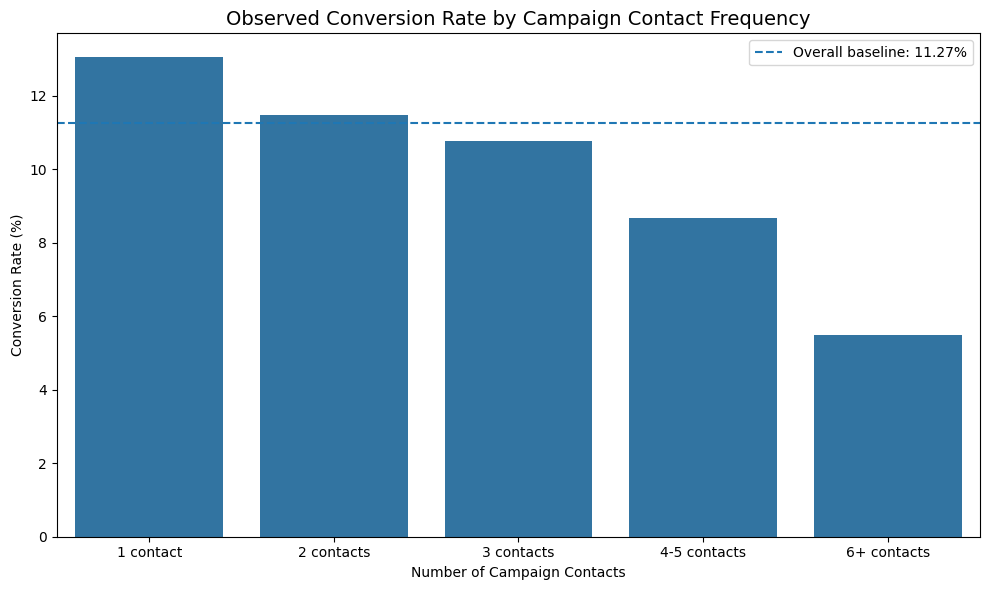

In [116]:
 plt.figure(figsize=(10, 6))

sns.barplot(
    data=campaign_analysis,
    x="campaign_group",
    y="conversion_rate"
)

plt.axhline(
    overall_conversion_rate,
    linestyle="--",
    label=f"Overall baseline: {overall_conversion_rate:.2f}%"
)

plt.title(
    "Observed Conversion Rate by Campaign Contact Frequency",
    fontsize=14
)

plt.xlabel("Number of Campaign Contacts")
plt.ylabel("Conversion Rate (%)")

plt.legend()

plt.tight_layout()
plt.show()

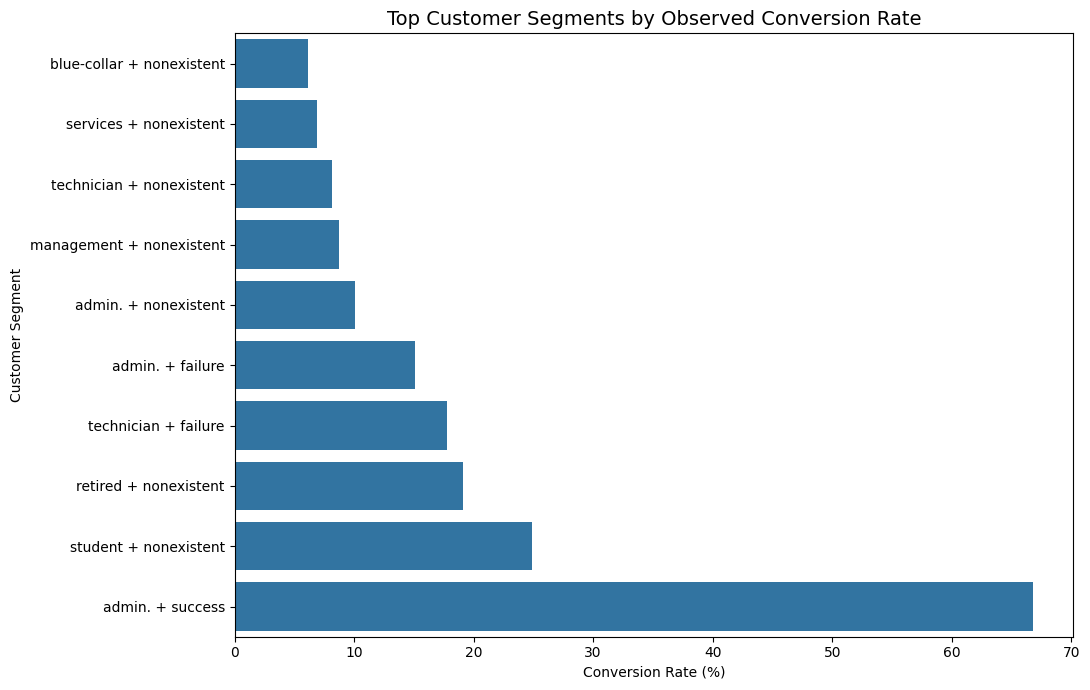

In [117]:
top_segments = (
    final_priority_table
    .head(10)
    .copy()
)

top_segments["segment"] = (
    top_segments["job"]
    + " + "
    + top_segments["poutcome"]
)

top_segments = (
    top_segments
    .sort_values("conversion_rate")
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_segments,
    x="conversion_rate",
    y="segment"
)

plt.title(
    "Top Customer Segments by Observed Conversion Rate",
    fontsize=14
)

plt.xlabel("Conversion Rate (%)")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

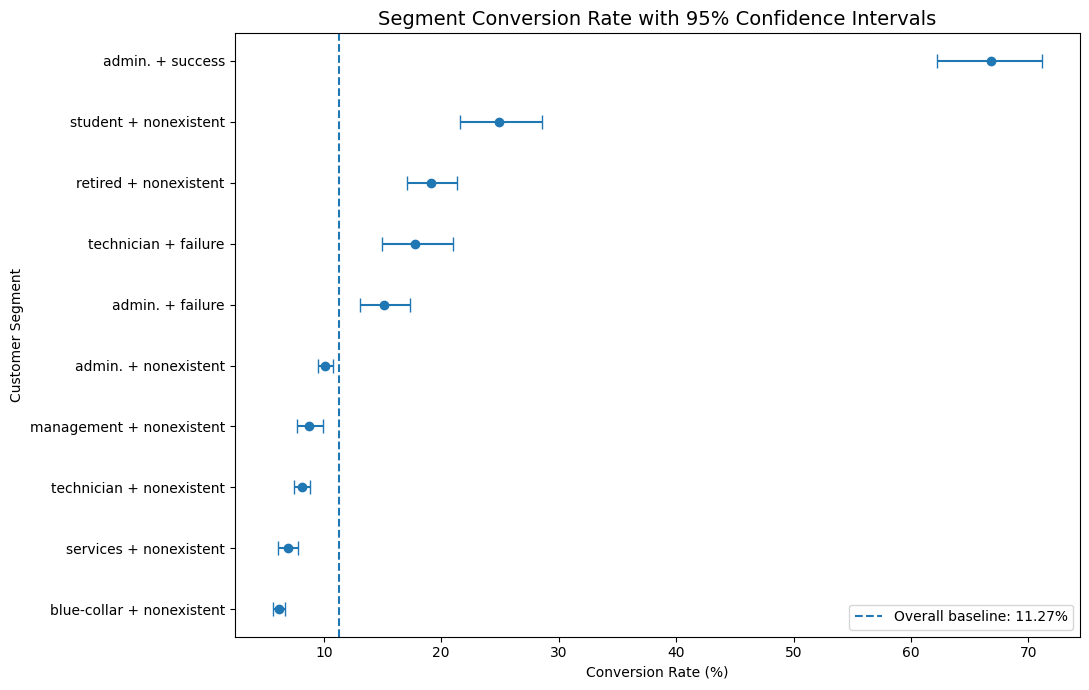

In [118]:
plot_data = (
    final_segment_analysis
    .head(10)
    .sort_values("conversion_rate")
    .copy()
)

y = np.arange(len(plot_data))

plt.figure(figsize=(11, 7))

plt.errorbar(
    plot_data["conversion_rate"],
    y,
    xerr=[
        plot_data["conversion_rate"] - plot_data["ci_lower"],
        plot_data["ci_upper"] - plot_data["conversion_rate"]
    ],
    fmt="o",
    capsize=5
)

plt.axvline(
    overall_conversion_rate,
    linestyle="--",
    label=f"Overall baseline: {overall_conversion_rate:.2f}%"
)

plt.yticks(
    y,
    plot_data["job"] + " + " + plot_data["poutcome"]
)

plt.xlabel("Conversion Rate (%)")
plt.ylabel("Customer Segment")

plt.title(
    "Segment Conversion Rate with 95% Confidence Intervals",
    fontsize=14
)

plt.legend()

plt.tight_layout()
plt.show()

## Conclusion

Through this project, I tried to understand how different customer and
campaign factors affect the success of a bank marketing campaign.

After cleaning and exploring the data, I found that the overall subscription
rate was around 11.27%. I also noticed that conversion rates were different
for different customer groups and campaign contact frequencies.

I used Python for data cleaning and analysis and SQL to perform additional
segmentation and ranking analysis. I also used conversion rate and relative
lift to compare different customer segments instead of looking only at the
number of subscriptions.

One interesting observation was that customers who had different previous
campaign outcomes showed noticeably different conversion behaviour. Campaign
contact frequency also showed a pattern where higher numbers of contacts did
not necessarily mean higher conversion.

Based on these findings, I created a simple prioritization approach to
identify customer segments that could be worth focusing on.

However, these are only observations from the available data. They do not
prove that one particular campaign strategy directly causes better
conversion. In a real business situation, these findings should be tested
through A/B testing before making major changes.

Overall, this project helped me understand how raw customer data can be
cleaned, analyzed and converted into useful business insights using Python,
SQL and data visualization.

## What I Learned

While working on this project, I learned how to:

- Clean and prepare a real-world dataset
- Handle missing and unknown values
- Create useful features for analysis
- Calculate conversion rate and relative lift
- Use SQL for customer segmentation and ranking
- Interpret data instead of only creating charts
- Convert analytical findings into practical business recommendations

In [119]:
# ============================================
# POWER BI EXPORT
# ============================================

powerbi_df = df.copy()

print("Power BI dataset shape:", powerbi_df.shape)

Power BI dataset shape: (41188, 21)
